# Estimating phytoplankton absorption from TOA radiance (modeling & calibration)

## Preamble
**Purpose.** This notebook consumes the **processed dataset** from `00_preprocessing.ipynb` and implements the **Bayesian modeling and evaluation**: linear (indep.), multivariate linear with covariance (MVN), and a BART benchmark (indep.). It generates all **paper figures/tables** and SI diagnostics.

**Data intake.** Reads `data/processed/aph_toa_ready.parquet` and `data/processed/schema.json` produced by the preprocessing notebook. **No additional corrections or re-transforms are applied here.**

---

### What this notebook does

0. **Environment setup & presets**

1. **Data intake & quick survey (first section)**
   - Load processed dataset and schema.
   - **Seaborn pairplot** on **log-domain** predictors/responses (KDE diagonals) to visualize distributions and pairwise structure.
   - Sanity checks (row count \(=163\); required bands present).

2. **Models**
   - **Linear (independent)**: separate Gaussian residuals per band.
   - **Multivariate linear (MVN)**: shared mean; **full residual covariance** (LKJ prior).
   - **BART benchmark (independent)**: nonlinear mean per band; **not** pursued with full covariance (underperformed linear indep.; \(N=163\) is modest).

3. **Inference**
   - PyMC v5 **NUTS** (default 4 chains; 2,000 tune + 2,000 draws).
   - Save `InferenceData` to `idata/`.

4. **Evaluation & diagnostics**
   - **PSIS-LOO** comparison (ΔLOO, SE; optional stacking weights).
   - **LOO-PIT** (KDE + ECDF−uniform deviation).
   - **Posterior predictive checks**; **predictive coverage** (50/80/95%).
   - Optional SI robustness: **band ablation** / **noise inflation**.

5. **Manuscript outputs**
   - `figs/fig1_obs_vs_pred_mvn.pdf`
   - `figs/fig2_loo_pit_mvn.pdf`
   - `figs/fig3_coverage_mvn.pdf`
   - `results/table1_model_compare.tex`
   - SI diagnostics saved as `Fig. S*` / `Table S*`.

---

### Notes & scope

- Predictive (conditional) task; not an IOP inversion.
- Predictors are **log\(_{10}\)** corrected TOA radiances (SeaWiFS 412–670 nm).
- Responses are **log\(_{10}\)** \(a_\phi\) at **443, 555, 670 nm**.
- **No standardization** of predictors.

---

### Environment presets & exports

- Prints Python/PyMC/ArviZ/NumPy/Matplotlib versions on start.
- Figures exported as **vector PDFs** at PNAS column widths; tables as LaTeX.
- All artifacts written under `figs/`, `results/`, `idata/`.


In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from itertools import combinations
from pathlib import Path

# ---------- DATA ----------
import pandas as pd
import numpy as np
import xarray as xr

# ---------- MODELING ----------

import pymc as pm
import pymc_bart as pmb
import pytensor.tensor as pt

# ---------- PLOTTING ----------

import matplotlib as mpl
import matplotlib.pyplot as pp
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import arviz as az
import seaborn as sb

# ---------- HOMEGROWN ----------

from scripts.model_utils import save_idata
from scripts.model_utils import find_influential_observations, posterior_coverage

from scripts.pnas_utils import set_pnas_style, fig_ax, save_pnas, pnas_figure, OKABE_ITO
from scripts.plot_utils import  plot_regression_hdi, plot_3_way_ppc, plot_ppc_hdi_band_multi
from scripts.plot_utils import plot_ppc_pit_grid, compare_ppc, plot_ppc_pit

In [4]:
print('Package Versions: ', end='\n' + 50*'--' + '\n')
print(f'PyMC - {pm.__version__}')
print(f'PyMC-BART - {pmb.__version__}')
print(f'PanDaS - {pd.__version__}')
print(f'Arviz - {az.__version__}')
print(f'Seaborn - {sb.__version__}')

Package Versions: 
----------------------------------------------------------------------------------------------------
PyMC - 5.20.1
PyMC-BART - 0.9.0
PanDaS - 2.2.3
Arviz - 0.21.0
Seaborn - 0.13.2


In [5]:
# A bit of setup
ROOT = Path(".").resolve()
DIR = {
    "data": ROOT / "data/03_transformed",
    "idata": ROOT / "inferencedata",
    "figs": ROOT / "figs",
    "results": ROOT / "results",
}
for d in DIR.values():
    d.mkdir(parents=True, exist_ok=True)

set_pnas_style(base_font_size=9)

In [6]:
# SOME CONFIGS 

# Common constants
APH_BANDS = [443, 555, 670]
TOA_BANDS = [412, 443, 490, 510, 555, 670]
MODEL_TAGS = {
    "model1_linear_diag": "linear_diag",
    "model2_bart_diag":   "bart_diag",
    "model3_linear_full": "linear_fullcov",
}

PNAS_WIDTH_IN = {"one": 3.43, "two": 7.00}
# Colorblind-safe mapping (Okabe–Ito)
BAND_COLORS = {
    443:  "#000000",  # blue
    555:  "#E69F00",  # green
    670:  "#56B4E9" ,  # vermillion
}
PPC_COLORS: list[str]= ['darkgray', 'k', 'C1']

legend_handles = [
    Line2D([0], [0], color=BAND_COLORS[443], lw=1.2, label="443 nm"),
    Line2D([0], [0], color=BAND_COLORS[555], lw=1.2, label="555 nm"),
    Line2D([0], [0], color=BAND_COLORS[670], lw=1.2, label="670 nm"),
]

In [7]:
# Last minute plot setting functions

def facet_height_for_pnas(ncols, width="two", aspect=1.0, min_height=1.0):
    target_w = PNAS_WIDTH_IN[width]
    return max(min_height, (target_w / max(1, ncols)) / aspect)

def save_model_dag(model, outpath, width="two", rankdir="LR", format='pdf'):
    W = 3.43 if width == "one" else 7.00  # inches
    g = pm.model_to_graphviz(model)
    g.graph_attr.update({
        "rankdir": rankdir,     # left→right often reads better
        "size": f"{W},{W*0.6}!",# width x height (force fit)
        "ranksep": "0.30",      # node layer spacing
        "nodesep": "0.25",      # sibling spacing
        "dpi": "300",
    })
    g.format = format
    stem = Path(outpath).with_suffix("")  # Graphviz adds .pdf
    g.render(filename=str(stem), cleanup=True)

In [8]:
# Load all saved InferenceData into a single dictionary
from scripts.model_utils import load_idata


# Map friendly names → file tags (tag.nc)
MODEL_TAGS = {
    "Linear (diag)":       "linear_diag",
    "BART (diag)":         "bart_diag",
    "Hier-Linear (diag)":  "hier_lin_diag",
    "Linear (full Σ)":     "linear_mvn",
}

# Load Inference Data Objects if the models below have already been fitted. Comment otherise.
idatas = {name: load_idata(tag, DIR["idata"]) for name, tag in MODEL_TAGS.items()}

# Optional: unpack for convenience
idata_lin  = idatas["Linear (diag)"]
idata_bart = idatas["BART (diag)"]
idata_hier = idatas["Hier-Linear (diag)"]
idata_mvn  = idatas["Linear (full Σ)"]

print("Loaded models:", ", ".join(idatas.keys()))

Loaded models: Linear (diag), BART (diag), Hier-Linear (diag), Linear (full Σ)


---
## Quick data survey

- Load the processed dataset from `00_preprocessing.ipynb`.
- Create a **seaborn pairplot** (KDE diagonals) on the **log-domain** variables to visualize distributions and pairwise relationships before fitting models.

### Load and prep data

In [9]:
df_log = pd.read_parquet(DIR['data'] / 'df_log.pqt') # Contains TOA radiance and Phytoplankton Absorption 
df_log.head()

,log_Rrc_412,log_Rrc_443,log_Rrc_490,log_Rrc_510,log_Rrc_555,log_Rrc_670,log_aph443,log_aph555,log_aph670
0,-1.917660,-1.905994,-1.930380,-1.975543,-2.040501,-2.176858,NaN,NaN,NaN
1,-1.977774,-1.973214,-2.017116,-2.101675,-2.205903,-2.319302,NaN,NaN,NaN
2,-2.352334,-2.357865,-2.372588,-2.433492,-2.577377,-2.929113,-1.511731,-2.414539,-1.982967
3,-2.231428,-2.231674,-2.256908,-2.333192,-2.478052,-2.757732,-1.641494,-2.508638,-2.029188
4,-2.023925,-2.047304,-2.112433,-2.223764,-2.380771,-2.599169,NaN,NaN,NaN


In [10]:
X = df_log.dropna().filter(regex='Rrc')
Y = df_log.dropna().filter(regex='aph')

### Visualize data

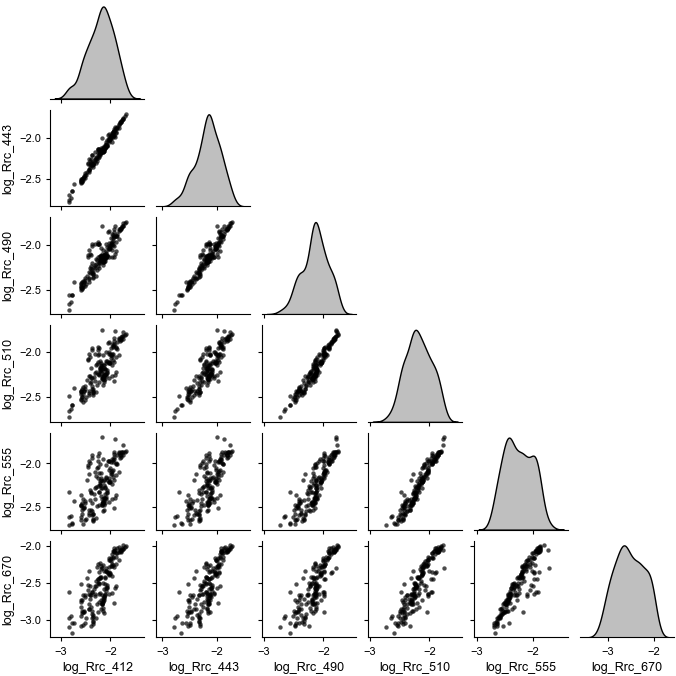

In [9]:
# Example: predictors-only corner plot (6 vars)
ncols = 6
height = facet_height_for_pnas(ncols, width="two", aspect=1.0, min_height=1.0)
g = sb.pairplot(X, corner=True, diag_kind="kde",
                 plot_kws=dict(s=10, alpha=0.7, linewidth=0),
                 height=height, aspect=1.0)
save_pnas(g.fig, DIR["figs"]/ "si" / "figS_pairplot_predictors.pdf")


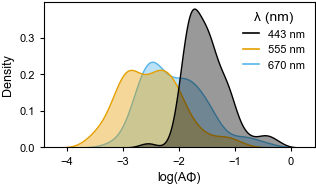

In [10]:
fig, ax = fig_ax(width="one", aspect=0.62)
ax = sb.kdeplot(Y, fill=True, alpha=0.4, legend=False, ax=ax)
ax.legend(handles=legend_handles, title='λ (nm)', frameon=False)
ax.set_xlabel('log(AΦ)')
ax.set_ylabel('Density')
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_kde_aph_overlaid.pdf")

# Modelling

## Bayesian workflow steps applied to all models

This section documents the **repeatable flow** I apply to each model so results are comparable and reproducible. If a step fails its checks, the use should stop and see if there is something to fix before proceeding. But nothing here is dogmatic; failures are suggestive of potential issues, and the user should exercise judgment (this part becomes easier with experience).

1. **Model specification.**  
   I define the likelihood and priors in the **log-domain** with consistent variable names (observed node: `likelihood`). For diagonal-$\Sigma$ models, residuals are independent across bands; for MVN, I parameterize a full covariance via an LKJ prior on correlations.

2. **Model DAG visualization.**  
   I render the computational graph to sanity-check dependencies and shapes. *Note:* for BART, Graphviz may show an arrow from $y$ to $\mu$—that reflects **inference dependencies** (residual updates), not the **generative DAG**.

3. **Prior predictive check (gate).**  
   I draw from the **prior predictive** and visualize summaries (cumulative/KDE). I verify that simulated $y$ spans plausible ranges for $\log_{10} a_\phi$ across bands.  
   **Decision rule:** if priors are too tight/too diffuse or clearly implausible, I **revise the priors or mean structure** and re-run the prior predictive **before** any posterior sampling.

4. **Posterior sampling (NUTS).**  
   I run NUTS with multiple chains, fixed seeds, and adequate tuning (default 2k tune + 2k draws unless otherwise noted). I store `log_likelihood`, `posterior_predictive`, and (when helpful) deterministic nodes like $\mu$.

5. **Sampling diagnostics (must pass).**  
   I evaluate:
   - **Summary:** $\hat{R}<1.01$ for all reported parameters; **bulk/tail ESS** comfortably into the **hundreds** (relative to total draws), and **MCSE** small relative to posterior SD.  
   - **Trace plots:** “fuzzy caterpillars” with good **chain overlap** and no stickiness or multimodal drift; no persistent trends across iterations.  
   - **Energy/BFMI:** **no divergences**; **BFMI ≥ 0.3** and **energy overlap** across chains; **max tree depth** not frequently saturated; step size stable.  
   If any of these fail, I adjust tuning, reparameterize (e.g., uncentered), or revisit priors.

6. **Posterior predictive checks & log-likelihood.**  
   I compute **posterior predictive** draws and visualize PPCs (by band and aggregated). I also compute and store **pointwise `log_likelihood`** for downstream PSIS-LOO, Pareto-$k$, and PIT.

7. **Fit, generalizability, and calibration diagnostics.**  
   I assess:
   - **PSIS-LOO model comparison:** report **ΔELPD** with **SE**, plus (optionally) stacking weights. I flag **influential observations** via **Pareto-$k$** (good < 0.5; caution 0.5–0.7; high > 0.7).  
   - **Uncertainty calibration:** **predictive coverage** at **50/80/95%** per band; **LOO-PIT** to detect miscalibration (U-shaped/∩-shaped/skewed).  
   - **Residual structure:** where relevant, inspect **posterior residual correlations** to motivate diagonal vs full $\Sigma$.  

**Presentation note.** For the main text, I show **LOO-PIT only for the final MVN model**; PIT for other models is included in **SI only if** ΔELPD is close or PPC/coverage indicate miscalibration worth documenting. All PPCs, coverage CSVs, Pareto-$k$ CSVs, and compare tables are exported with **standardized filenames**.


## Preparation

Note that I do not use, nor recommend, pre-processing steps that are parameterized using the training data (the data used for model development). 
The point of Bayesian Modeling is to approximate the data generation process, and not the data. However such pre-processing steps - e.g. standardization,
or dimensional reduction via PCA/EOF incidentally render the model dependent on training data. I therefore limit any transformation to endogenous operation; log-transformation of inputs and outputs in the present case.

In [48]:
x_idx, x_names = X.columns.factorize()
y_idx, y_names = Y.columns.factorize()
λ =   [li.split('Rrc_')[-1] for li in x_names]
λ_aph =   [li.split('aph')[-1] for li in y_names]
coords= {
    'obs_idx': X.index,
    'λ_toa': λ, 
    'λ_aφ' : λ_aph
}

## A — Models with (diagonal Σ) residual structure  to isolate mean-function effects

###  Model 1 — Linear mean with diagonal $\Sigma$ (baseline)

**Why this model.**  
Simplest parametric baseline. Keeps residuals **independent across bands** (diagonal $\Sigma$) to isolate the effect of the **mean function**. Mild Gaussian priors help with the known **collinearity** among TOA radiances without standardizing predictors.

**Model (log-domain).**  
For $k\in\{443,555,670\}$ and $j\in\{1,\dots,6\}$:
$$
y_{i,k}\mid \mu_{i,k},\sigma_k \sim \mathcal{N}(\mu_{i,k},\sigma_k^2),\qquad
\mu_{i,k}=\alpha_k+\sum_{j=1}^6 \beta_{j,k}\,x_{i,j},
$$
$$
\alpha_k\sim\mathcal{N}(0,1),\quad \beta_{j,k}\sim\mathcal{N}(0,1),\quad
\sigma_k\sim\mathrm{Exponential}(1).
$$
Observed node is named **`likelihood`**.

#### 1) Model Code

In [49]:
# simple linear model first as benchmark
with pm.Model(coords=coords) as m_lin: 
    X_data = pm.Data(
        'log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data(
        'log_aφ', Y, dims=['obs_idx', 'λ_aφ'])
    α = pm.Normal('α', 0, 1, dims='λ_aφ')
    β = pm.Normal('β', 0, 1, dims=['λ_toa', 'λ_aφ'])
    μ = α + X_data @ β
    σ = pm.Exponential('σ', 1, dims='λ_aφ')
    likelihood = pm.Normal(
        'likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])


#### 2) Model DAG visualization
- Sanity-check parent/child relationships and tensor shapes.  

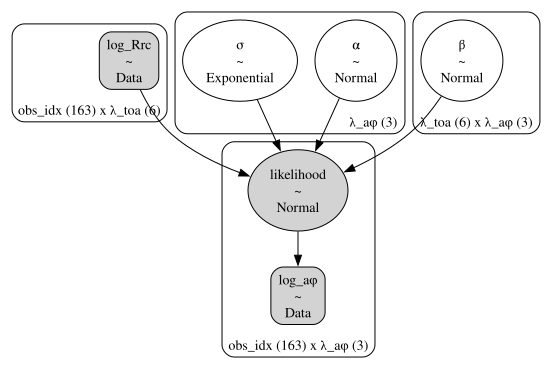

In [50]:
g1 = m_lin.to_graphviz()
g1

In [52]:
g1.render("m1_dag", directory=str(DIR['figs'] / 'portfolio'), format='png', cleanup=True)
g1.render("m1_linear_dag", directory=str(DIR["figs"]/ "si"), format="pdf", cleanup=True)

'/Users/erdemkarakoylu/projex/bayesian_toa_2_iop/figs/si/m1_linear_dag.pdf'

In [16]:
save_model_dag(m_lin, DIR["figs"]/ "si" / "figS_dag_linear_diag.pdf", width="two")
save_model_dag(m_lin, DIR['figs'] / 'portfolio' / 'm1_dag.png', format='png', width="two")

#### 3) Prior predictive check  
- Visualize prior predictive vs. observed ranges (e.g., cumulative or KDE).  
- Decision rule: if implausible/tight/diffuse → adjust priors/structure **before** sampling.  
**Result notes:** [does prior predictive bracket plausible $\log_{10}a_\phi$? → ______]  
**Artifact:** [prior PPC fig path → ______]

In [ ]:
with m_lin:
    idata_lin = pm.sample_prior_predictive()

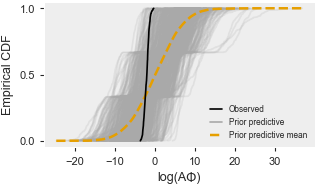

In [490]:
fig, ax = fig_ax(width="one", aspect=0.62)
az.plot_ppc(
    idata_lin, group='prior', kind='cumulative', 
    colors=PPC_COLORS, observed=True, ax=ax)

ax.set_xlabel('log(AΦ)')
ax.set_ylabel('Empirical CDF')
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_prior_ppc_linear_diag.pdf")

#### 4) Posterior sampling (NUTS)

- Settings: [chains = 4, tune = 1000 , draws = 2000/chain, target_accept = 0.80 (default)].  
- Stored: `log_likelihood`, `posterior_predictive`, [and `μ` if available].  
**Result notes:** [No warnings/divergences]


In [280]:
with m_lin:
    idata_lin.extend(pm.sample(chains=4, draws=2000))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, σ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 134 seconds.


#### 5) Sampling diagnostics

##### a. Summary statistics

- $\hat{R}$ to assess convergence of independent MCMC chains
    * should be about 1.0 - 1.01
- Effective Sample Size (ESS) to verify sufficient independent samples were collected in key areas of the posterior. 
    * should be in the high 100s to 1000s
- check for r_mcse to confirm posterior sampling was adequate
    * should be much less than 0.05




In [ ]:
summ = az.summary(idata_lin, var_names=["α","β","σ"])
summ

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α[443],-2.278,0.160,-2.573,-1.967,0.002,0.002,10292.0,6466.0,1.0
α[555],-3.122,0.266,-3.581,-2.577,0.003,0.004,11149.0,5252.0,1.0
α[670],-3.884,0.201,-4.243,-3.496,0.002,0.002,10467.0,5830.0,1.0
"β[412, 443]",0.993,0.508,0.044,1.964,0.006,0.006,6652.0,5582.0,1.0
"β[412, 555]",-0.074,0.586,-1.194,1.021,0.007,0.007,6550.0,4554.0,1.0
"β[412, 670]",0.333,0.546,-0.670,1.353,0.007,0.006,6268.0,5709.0,1.0
"β[443, 443]",-1.793,0.764,-3.255,-0.383,0.009,0.009,6992.0,5476.0,1.0
"β[443, 555]",-1.459,0.801,-2.979,0.039,0.009,0.010,7642.0,5319.0,1.0
"β[443, 670]",-1.634,0.782,-3.131,-0.219,0.010,0.009,6454.0,5191.0,1.0
"β[490, 443]",-2.270,0.695,-3.527,-0.905,0.008,0.007,7428.0,6074.0,1.0


In [501]:
summ["rMCSE_mean"] = summ["mcse_mean"] / summ["sd"]
summ["rMCSE_sd"]   = summ["mcse_sd"]   / summ["sd"]
summ[["rMCSE_mean","rMCSE_sd","ess_bulk","ess_tail","r_hat"]].describe()

,rMCSE_mean,rMCSE_sd,ess_bulk,ess_tail,r_hat
count,24.000000,24.000000,24.000000,24.000000,24.0
mean,0.010317,0.009966,7512.833333,5614.583333,1.0
std,0.004054,0.004035,1471.031837,421.178772,0.0
min,0.000000,0.000000,6114.000000,4554.000000,1.0
25%,0.011096,0.010250,6586.750000,5300.750000,1.0
50%,0.011682,0.011144,6869.500000,5645.500000,1.0
75%,0.012346,0.011845,7936.750000,5933.750000,1.0
max,0.012876,0.015038,11149.000000,6466.000000,1.0


##### b. Energy plots


The Energy plot for HMC helps assess how efficiently the sampler is exploring the posterior distribution. This plot helps assess how efficiently the sampler is exploring the posterior distribution. It shows two key distributions:

* Marginal Energy: The distribution of the Hamiltonian energy values across all samples. This is essentially a measure of the total "energy" (potential + kinetic) of the system at each sample.
* Energy Transition: The distribution of differences in energy between successive samples (i.e., energy jumps). Ideally, the transitions should be smooth and not show large jumps.

These matter because efficient HMC sampling assumes the energy landscape is smooth and traversable. Large or erratic energy transitions may indicate problems such as:

* Poor geometry (e.g., highly curved posteriors)
* Bad parameter scaling or priors
* Sampling stuck in narrow funnels or high-curvature areas


$⇒$ What BFMI Means:

BFMI = Bayesian Fraction of Missing Information

It quantifies how well the momentum resampling step in HMC is helping explore the energy landscape:
$$BFMI=\frac{Var(marginal energy)}{Var(energy transition)}$$
​

A low BFMI means the sampler isn't drawing enough momentum to explore distant parts of the posterior, which can result in biased samples or poor mixing.

$⇒$ What is a Good BFMI Value?

* BFMI ≥ 0.3 is generally considered acceptable.
* BFMI < 0.2 is a red flag indicating poor exploration and possible divergences.
* Ideally, values closer to 1 are better — indicating momentum is appropriately scaled to traverse the typical set efficiently.

$⇒$ How to Use the Plot:

* Compare the marginal energy and energy transition distributions. If they differ sharply, or if BFMI is low, your sampler may be inefficient.
* In ArviZ, low BFMI is often reported with a warning. There may also be differences in the plot (e.g., the energy transition distribution is narrow relative to the marginal energy).

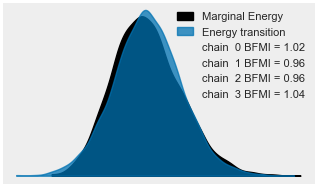

In [502]:
fig, ax = fig_ax()
az.plot_energy(idata_lin, ax=ax)
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_energy_linear_diag.pdf")

##### c. Trace plots 
* Left: Marginal posteriors (of parameters)
    * Visually assess of convergence (distribution overlap)
    * Parameter distribution estimation
* Right: Independent Sampling chains
    * Assess mixing quality $→$ should look like fuzzy caterpilars with no obvious trends



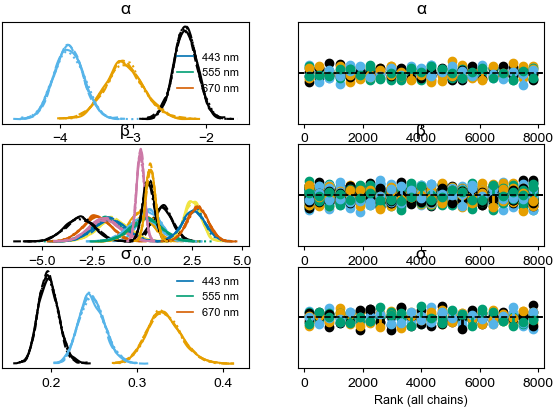

In [17]:
# Trace (compact) for a small var set — SI only
axs = az.plot_trace(
    idata_lin, compact=True, kind="rank_vlines",
    figsize=(7.0, 4.5))
axs[0, 0].legend(handles=legend_handles)
axs[2, 0].legend(handles=legend_handles)

f = pp.gcf()
f.savefig(DIR["figs"]/"si"/"figS_m1_trace.pdf"); 

#### 6) Estimating model performance on: 

* In-sample data
    - Compute Posterior predictive checks & log-likelihood,
    - Can the model generate data similar to that seen during training

* Out-of-sample (future) data
    - Compute Pareto Smooth Importance Sampling (PSIS) Leave-One-Out (LOO) cross validation
    - Assess Pareto-k to detect possible presence of overly influential data
    - Compute & Plot Predictive Coverage
    - Assess calibration of uncertainties using LOO - Probability Integral Transform (PIT)

In [ ]:
with m_lin:
    idata_lin.extend(pm.sample_posterior_predictive(idata_lin))
    _ = pm.compute_log_likelihood(
        idata_lin, extend_inferencedata=True)


Sampling: [likelihood]


Output()

##### a. Posterior Predictive Checks

###### - 3-way posterior predictive check

$→$ Goal: Visual check that replicated data from the fitted model resemble the observed distribution at each wavelength; large mismatches suggest mean/variance mis-specification.

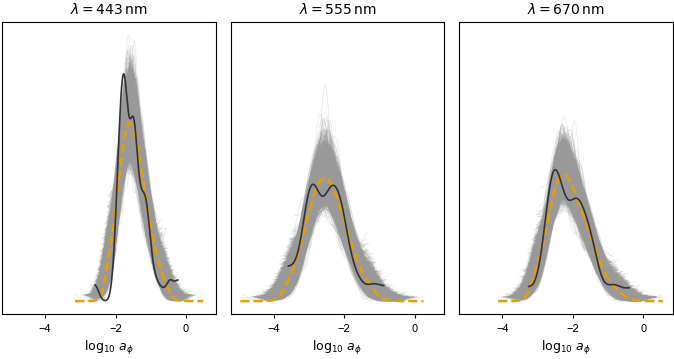

In [9]:
f, axs = plot_3_way_ppc(
    idata=idata_lin, var="likelihood",
    out=DIR["figs"] / "si" / f"figS_m1_ppc.pdf"
    )
f.savefig(DIR['figs'] / 'portfolio' /'mi_ppc.png', )

###### - Prior vs posterior predictive

$→$ Goal: Contrast the prior predictive (model+priors only) with the posterior predictive (after seeing data) to show that priors are reasonable and the data are informative.

(<Figure size 700.787x434.488 with 2 Axes>,
 array([<Axes: title={'center': 'Prior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(443\\,\\mathrm{nm})$'>,
        <Axes: title={'center': 'Posterior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(443\\,\\mathrm{nm})$'>],
       dtype=object))

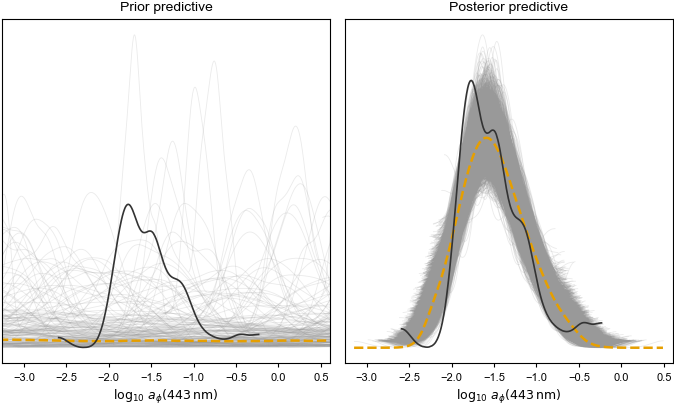

In [ ]:
# SI Figure: Prior vs Posterior PPC (band 443); falls back to posterior-only if no prior saved
band = 443
f, axs=compare_ppc(
    idata_lin, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m1_compare_ppc_{band}.pdf"
)

(<Figure size 700.787x434.488 with 2 Axes>,
 array([<Axes: title={'center': 'Prior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(555\\,\\mathrm{nm})$'>,
        <Axes: title={'center': 'Posterior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(555\\,\\mathrm{nm})$'>],
       dtype=object))

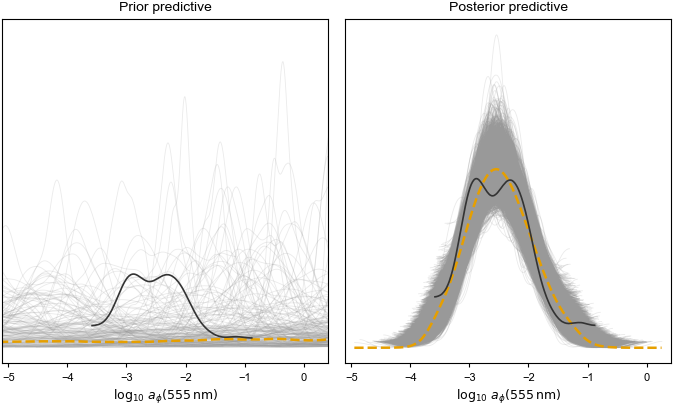

In [ ]:
# SI Figure: Prior vs Posterior PPC (band 555); falls back to posterior-only if no prior saved
band = 555
f, axs = compare_ppc(
    idata_lin, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m1_compare_ppc_{band}.pdf"
)

(<Figure size 700.787x434.488 with 2 Axes>,
 array([<Axes: title={'center': 'Prior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(670\\,\\mathrm{nm})$'>,
        <Axes: title={'center': 'Posterior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(670\\,\\mathrm{nm})$'>],
       dtype=object))

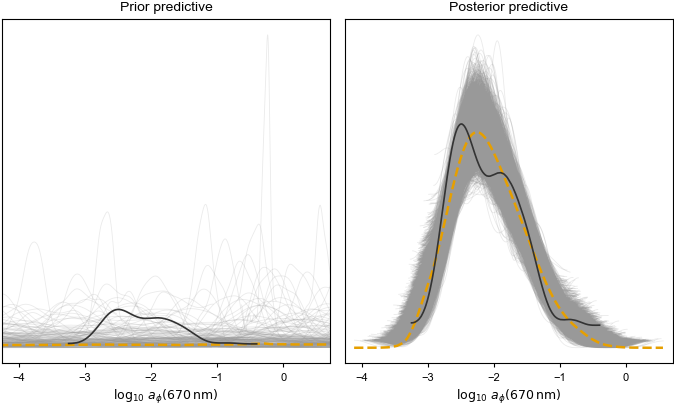

In [ ]:
# SI Figure: Prior vs Posterior PPC (band 670); falls back to posterior-only if no prior saved
band = 670
f, axs=compare_ppc(
    idata_lin, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m1_compare_ppc_{band}.pdf"
)

##### b. Coverage and Uncertainty Calibration
###### - Coverage

$→$ Goal: Observation-level calibration and bias check: do observed points fall within 50/80/95% predictive intervals, and are there runs of misses or fanning (heteroscedasticity)?

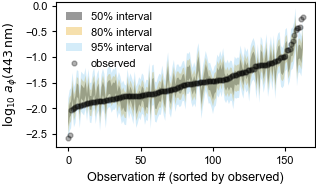

In [14]:
# SI Figure: HDI ribbons vs observed (band 443)
band=443
f, ax = plot_regression_hdi(
    idata_lin, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_linear_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /'mi_hdi_443.png', )

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hd

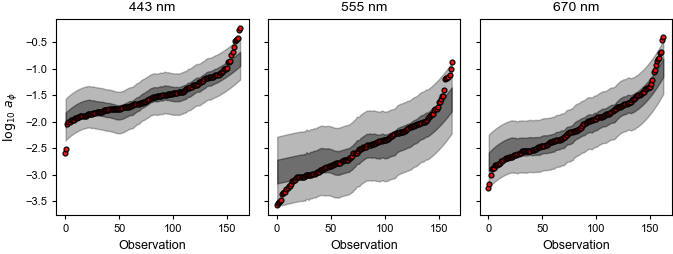

In [36]:
bands = [443, 555, 670]
fig, axes = pp.subplots(1, len(bands), figsize=(7.0, 7.0*0.4), sharey=True)

stats_list = []
for i, (ax_i, b) in enumerate(zip(axes, bands)):
    df_b = plot_ppc_hdi_band_multi(
        idata=idata_lin, band=b, hdi_probs=(0.95, 0.50),
        sort_by="observed", ax=ax_i  # <- draw into existing axes
    )
    stats_list.append(df_b)
    ax_i.set_title(f"{b} nm")  # optional; your call
    if i > 0: ax_i.set_ylabel('')  # only leftmost panel
fig.tight_layout()
save_pnas(fig, "figs/si/figS_m1_ppc_multi")
fig.savefig(DIR['figs'] / 'portfolio' /'m1_ppc_multi.png', )
stats_all_lin = pd.concat(stats_list, ignore_index=True)  # table-ready


In [23]:
stats_all_lin

,band,hdi_prob,n_obs,max_width_log,median_width_log,p90_width_log,max_factor,median_factor,p90_factor,factor_base
0,443,0.95,163,0.819002,0.787387,0.802735,6.591777,6.128967,6.349430,10.0
1,555,0.95,163,1.397663,1.320868,1.348499,24.984043,20.934752,22.309955,10.0
2,670,0.95,163,1.040230,0.987964,1.009039,10.970592,9.726658,10.210315,10.0


<u>**Predictive uncertainty by band (95% posterior predictive HDI; n = 163 per band)**</u>

These summaries report the **vertical span** of the posterior predictive highest-density interval (HDI) for each observation, in **log10 units** (widths) and as **multiplicative factors** (×). Because these are **posterior predictive** intervals, they combine both mean-function and residual uncertainty.

* 443 nm
  - **Median span:** 0.787 log10 → **×6.13**
  - **P90 span:** 0.803 log10 → **×6.35**
  - **Maximum span:** 0.819 log10 → **×6.59**

*Interpretation:* Typical uncertainty is ~6× (well below a full order of magnitude).

* 555 nm
  - **Median span:** 1.321 log10 → **×20.93**
  - **P90 span:** 1.349 log10 → **×22.31**
  - **Maximum span:** 1.398 log10 → **×24.98**

*Interpretation:* Uncertainty is **much larger** here—~21× on typical observations (well over one order of magnitude).

* 670 nm
  - **Median span:** 0.988 log10 → **×9.73**
  - **P90 span:** 1.009 log10 → **×10.21**
  - **Maximum span:** 1.040 log10 → **×10.97**

*Interpretation:* Typical uncertainty is ~one order of magnitude; the widest envelopes approach ~11×.

**Cross-band takeaway.** Predictive uncertainty is **lowest at 443 nm** (~6×), **highest at 555 nm** (~21×), and **intermediate at 670 nm** (~10×). This pattern suggests higher model/data uncertainty in the green band, with the blue band comparatively most precise.

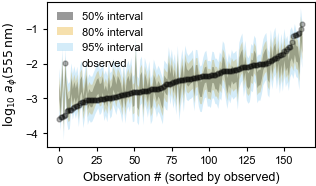

In [ ]:
# SI Figure: HDI ribbons vs observed (band 555)
band=555
f, ax = plot_regression_hdi(
    idata_lin, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_linear_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /'mi_hdi_555.png', )

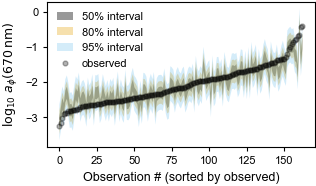

In [17]:
# SI Figure: HDI ribbons vs observed (band 670)
band=670
f, ax = plot_regression_hdi(
    idata_lin, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_linear_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /'mi_hdi_670.png', )

> What is coverage here:  the fraction of observations (for that band) whose observed values lie inside the model’s posterior predictive central interval at the given nominal level. If coverage < nominal, the predictive is under-dispersed; if coverage > nominal, it’s over-dispersed. (Note: this is in-sample posterior predictive coverage, not LOO unless you compute LOO predictive draws.)

In [10]:
# (Optional) SI Table: Coverage per band
cov_lin = posterior_coverage(idata_lin, var="likelihood")
cov_lin.to_csv(DIR["results"]/ "coverage_linear_diag.csv", index=False)
cov_lin

,interval,band,coverage,nominal
0,95%,443,0.963190,0.95
1,95%,555,0.963190,0.95
2,95%,670,0.963190,0.95
3,80%,443,0.858896,0.80
4,80%,555,0.871166,0.80
5,80%,670,0.834356,0.80
6,50%,443,0.533742,0.50
7,50%,555,0.558282,0.50
8,50%,670,0.570552,0.50


###### - PPC + LOO-PIT

$\rightarrow$ Goal: Pair overall fit (PPC) with calibration (LOO-PIT); a near-uniform LOO-PIT indicates well-calibrated predictive distributions for this band.

In-sample posterior predictive coverage often skews a bit high (optimistic). That’s normal.

To judge calibration more strictly, rely on LOO-PIT (and/or compute LOO predictive coverage)—those account for re-use of the data.

If LOO-PIT shows a gentle hump near 0.5 (rather than U-shape), that aligns with overdispersion; if it’s close to uniform, you’re fine.
Check whether there are no overly influential values that can undermine PSI-LOO-CV

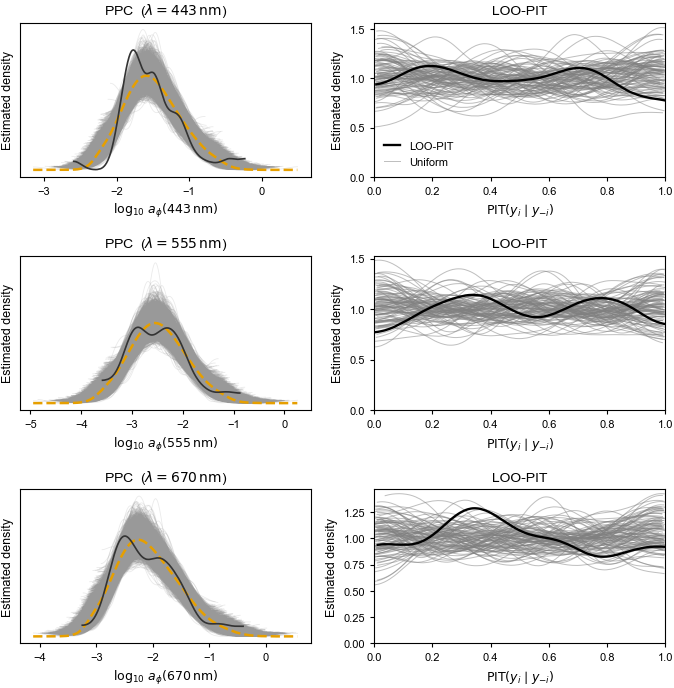

In [10]:
# All three bands in one 3×2 figure
f, axs = plot_ppc_pit_grid(
    idata_lin, var="likelihood",
    out=DIR["figs"]/ "si"/ "figS_ppc_pit_grid_linear_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /'mi_ppc_pit_grid.png', )


###### - LOO-PIT quality assessment via Pareto-k influential observations

$→$ Goal: Flag observations with high influence on PSIS-LOO (e.g., k > 0.7) to assess robustness and diagnose leverage points.

In [26]:
infl_idx, k_values, loo_result = find_influential_observations(idata_lin)
"Influential Values detected" if len(infl_idx) else "No overly influential values to undermine PSIS-LOO"

'No overly influential values to undermine PSIS-LOO'

#### 7) Save Inference Data object

In [508]:
save_idata(idata_lin, DIR["idata"], "linear_diag")

PosixPath('/Users/erdemkarakoylu/projex/bayesian_toa_2_iop/inferencedata/linear_diag.nc')

---
### Model 2 — BART mean with diagonal covariance (nonlinear benchmark)

**Why this model**  
The six TOA radiance predictors are **highly correlated** across wavelengths. A tree ensemble like **BART** can absorb collinearity and possible weak nonlinearities/interactions without pre-specifying them. I present this *nonlinear* benchmark **before** the linear baselines to show what additional flexibility buys. It matches the Linear model'sresidual assumption, so differences in performance isolate **mean-function flexibility** to contrast simplicity vs. flexibility.

** Variables (log-domain)
- Predictors per observation $i$: $\mathbf{x}_i \in \mathbb{R}^6$ ordered as $[412,443,490,510,555,670]$ (log$_{10}$ radiances).
- Responses per observation $i$: $\mathbf{y}_i=(y_{i,443},y_{i,555},y_{i,670})^\top$ where $y_{i,k}=\log_{10} a_\phi(\lambda_k)$.
- **No standardization** of predictors (predictive setting).

**Model definition**
I fit **separate BART mean functions per band** with a **shared** hyperparameter setting and **independent Gaussian residuals** across bands (diagonal covariance):
$$
\mu_{i,k} \equiv f_{\lambda_k}(\mathbf{x}_i), \qquad
f_{\lambda_k} \sim \mathrm{BART}(m=10,\ \alpha=0.9,\ \beta=4), \qquad k\in\{443,555,670\}.
$$
$$
y_{i,k}\mid \mu_{i,k},\sigma_k \sim \mathcal{N}(\mu_{i,k},\,\sigma_k^2), 
\qquad \sigma_k \sim \mathrm{HalfNormal}(0.5).
$$
Vector form:
$$
\mathbf{y}_i \sim \mathcal{N}\!\big(\boldsymbol{\mu}_i,\ \mathrm{diag}(\boldsymbol{\sigma}^2)\big),
\qquad
\boldsymbol{\mu}_i = \big(f_{443}(\mathbf{x}_i),f_{555}(\mathbf{x}_i),f_{670}(\mathbf{x}_i)\big)^\top,
\quad
\boldsymbol{\sigma} = (\sigma_{443},\sigma_{555},\sigma_{670})^\top.
$$

**Hyperparameter intent.**  

* $m=10$ (modest ensemble size)
* $\alpha=0.9$ (shallower trees) 
* regularize structure at $N=163$; 
* $\beta=4$ shrinks terminal-node means; 
* $\mathrm{HalfNormal}(0.5)$ is a weakly-informative residual-scale prior per band.

#### 1) Model Code


In [53]:
with pm.Model(coords=coords) as m_bart:
    X_data = pm.Data('log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y, dims=['obs_idx', 'λ_aφ'])
    σ = pm.HalfNormal('σ', 0.5, dims='λ_aφ')
    μ = pmb.BART('μ', X=X_data, Y=Y_data, m=10, alpha=0.9, beta=4, dims=('λ_aφ', 'obs_idx')).T
    pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])

#### 2) Model DAG visualization
- Sanity-check parent/child relationships and tensor shapes.  

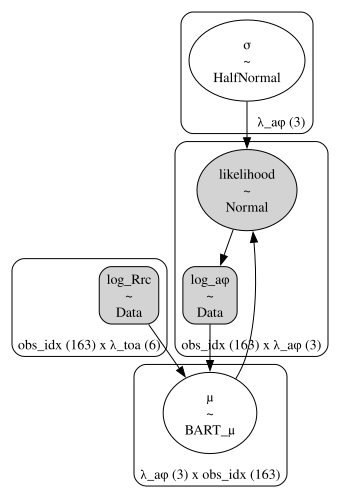

In [54]:
g2 = m_bart.to_graphviz()
g2

In [55]:
#g2.render("m2_bart_dag", directory=str(DIR["figs"]/ "si"), format="pdf", cleanup=True)
g2.render("m2_dag", directory=str(DIR['figs'] / 'portfolio'), format='png', cleanup=True)

'/Users/erdemkarakoylu/projex/bayesian_toa_2_iop/figs/portfolio/m2_dag.png'

**Note on the BART model graph.**  
You may see an arrow from the observed node $\,\texttt{log\_a}\phi\,$ to the BART mean $\mu$ in the Graphviz output. This is **not** part of the generative DAG. The generative story is
$$
\mathbf{x}\;\to\;\mu=f(\mathbf{x})\;\to\;y\sim\mathcal{N}(\mu,\sigma^2),\qquad \sigma\to y,
$$
i.e., $y$ depends on $(\mu,\sigma)$, and $\mu$ depends on $\mathbf{x}$.

The extra arrow reflects **computational/inference dependencies** in PyMC’s implementation of BART: internally, the observed data $y$ are used to form residuals and drive the tree backfitting/update steps. Graphviz shows that implementation detail as a dependency (to support posterior updates), but it **does not** mean the BART **prior** is conditioned on $y$. In other words, treat the arrow as part of the **inference graph**, not the **probabilistic DAG**.


In [ ]:
save_model_dag(m_bart, DIR["figs"]/ "si" / "figS_m2_dag.pdf", width="two")
save_model_dag(m_bart, DIR['figs'] / 'portfolio' / 'm2_dag.png', format='png', width="two")

#### 3) Prior predictive check
- Visualize prior predictive vs. observed ranges 

In [29]:
with m_bart:
    idata_bart = pm.sample_prior_predictive()

Sampling: [likelihood, μ, σ]


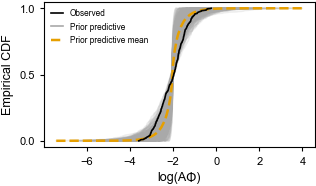

In [41]:
fig, ax = fig_ax(width="one", aspect=0.62)
az.plot_ppc(
    idata_bart, group='prior', kind='cumulative', 
    colors=PPC_COLORS, observed=True, ax=ax)

ax.set_xlabel('log(AΦ)')
ax.set_ylabel('Empirical CDF')
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_m2_prior_ppc.pdf")

#### 4) Posterior sampling (NUTS).**  
- Settings: [chains = 4, tune = 1000 , draws = 2000/chain, target_accept = 0.80 (default)].  
- Stored: `log_likelihood`, `posterior_predictive`, [and `μ` if available].  
**Result notes:** [No warnings/divergences]


In [31]:
with m_bart:
    idata_bart.extend(pm.sample(draws=2000, chains=4, target_accept=0.95))

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [σ]
>PGBART: [μ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Some issues with r-hat but might be okay.

#### 5) Sampling diagnostics

##### a. Summary statistics, examining
    

In [ ]:
summ = az.summary(idata_bart)
summ

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"μ[443, 2]",-1.462,0.115,-1.679,-1.250,0.003,0.002,1090.0,1923.0,1.00
"μ[443, 3]",-1.496,0.108,-1.711,-1.305,0.003,0.002,1174.0,1943.0,1.00
"μ[443, 26]",-1.683,0.118,-1.908,-1.467,0.004,0.002,979.0,1814.0,1.01
"μ[443, 31]",-1.408,0.118,-1.626,-1.188,0.004,0.002,1036.0,1889.0,1.00
"μ[443, 32]",-1.503,0.118,-1.718,-1.281,0.004,0.002,1045.0,1905.0,1.01
...,...,...,...,...,...,...,...,...,...
"μ[670, 492]",-2.010,0.186,-2.378,-1.673,0.006,0.003,1074.0,1789.0,1.00
"μ[670, 494]",-1.891,0.185,-2.235,-1.548,0.006,0.004,1110.0,1871.0,1.01
σ[443],0.359,0.031,0.300,0.415,0.001,0.000,1224.0,2539.0,1.00
σ[555],0.500,0.046,0.420,0.589,0.001,0.001,1465.0,2920.0,1.00


In [512]:
summ["rMCSE_mean"] = summ["mcse_mean"] / summ["sd"]
summ["rMCSE_sd"]   = summ["mcse_sd"]   / summ["sd"]
summ[["rMCSE_mean","rMCSE_sd","ess_bulk","ess_tail","r_hat"]].describe()

,rMCSE_mean,rMCSE_sd,ess_bulk,ess_tail,r_hat
count,492.000000,492.000000,492.000000,492.000000,492.000000
mean,0.029543,0.017472,1121.166667,1940.715447,1.003211
std,0.002554,0.002133,90.354679,207.624672,0.004674
min,0.021739,0.000000,897.000000,1295.000000,1.000000
25%,0.027473,0.016216,1057.000000,1813.750000,1.000000
50%,0.028986,0.016949,1121.500000,1941.000000,1.000000
75%,0.031543,0.018349,1187.250000,2073.000000,1.010000
max,0.036496,0.025424,1475.000000,2920.000000,1.010000


##### b. Energy plots

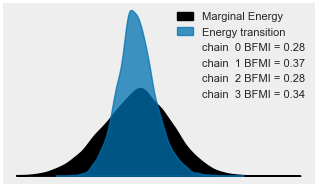

In [513]:
fig, ax = fig_ax()
az.plot_energy(idata_bart, ax=ax)
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_m2_energy.pdf")

OK overlap, BFMI is a little low in two of the chains (should be >0.3)

##### c. Trace plots

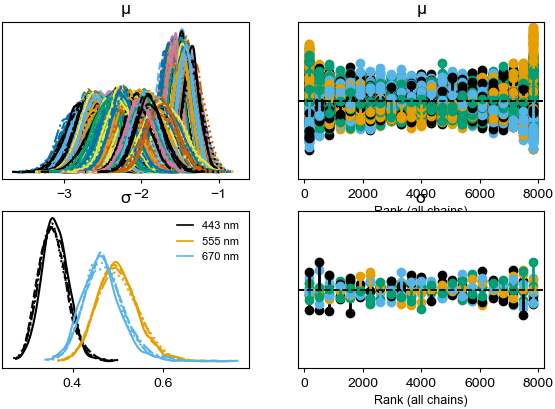

In [27]:
# Trace (compact) for a small var set — SI only
axs = az.plot_trace(
    idata_bart, compact=True, kind="rank_vlines",
    figsize=(7.0, 4.5))
axs[1, 0].legend(handles=legend_handles)
#axs[2, 0].legend(handles=legend_handles)

f = pp.gcf()
f.savefig(DIR["figs"]/"si"/"figS_m2_trace.pdf"); 

Next is to simulate $log(aΦ)$ from the posterior; posterior predictive checks

#### 6) Esimating model performance on:

In [ ]:
with m_bart:
    idata_bart.extend(pm.sample_posterior_predictive(idata_bart))

##### a. Posterior Predictive Checks
###### - 3-way posterior predictive check

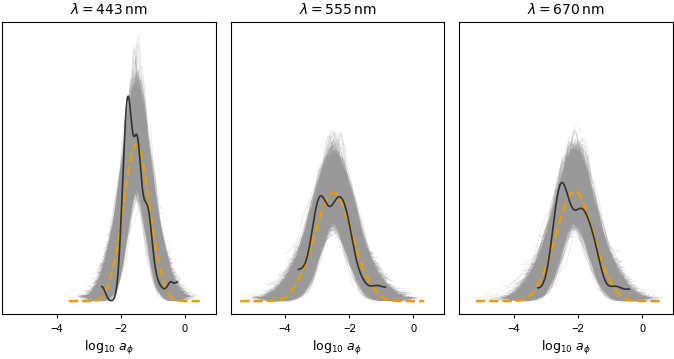

In [28]:
f, axs = plot_3_way_ppc(
    idata=idata_bart, var="likelihood",
    out=DIR["figs"] / "si" / f"figS_m2_ppc.pdf"
    )
f.savefig(DIR['figs'] / 'portfolio' /'m2_ppc.png')

###### - Prior vs posterior predictive

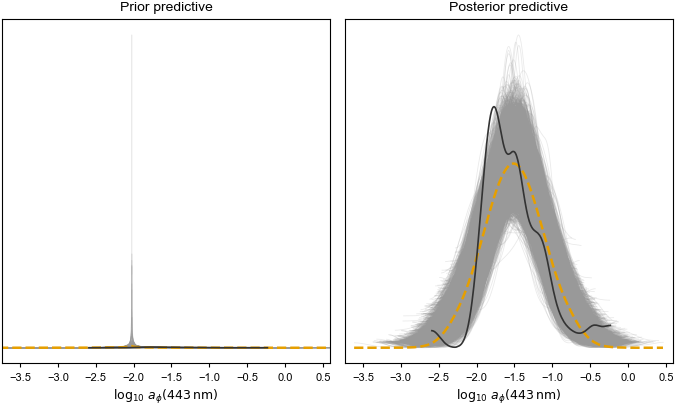

In [29]:
# SI Figure: Prior vs Posterior PPC (band 670); falls back to posterior-only if no prior saved
band = 443
f, axs=compare_ppc(
    idata_bart, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m2_compare_ppc_{band}.pdf"
)

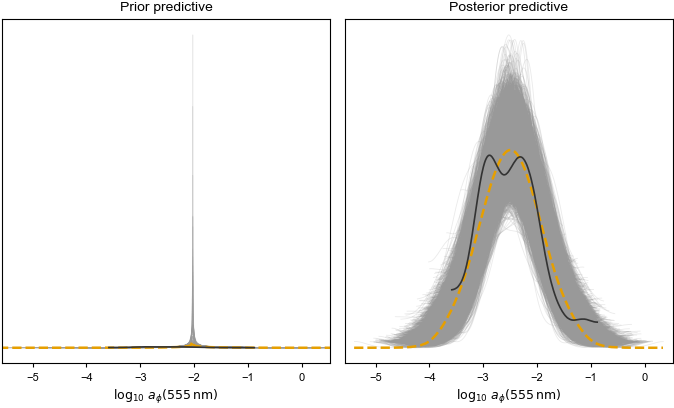

In [30]:
# SI Figure: Prior vs Posterior PPC (band 670); falls back to posterior-only if no prior saved
band = 555
f, axs=compare_ppc(
    idata_bart, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m2_compare_ppc_{band}.pdf"
)

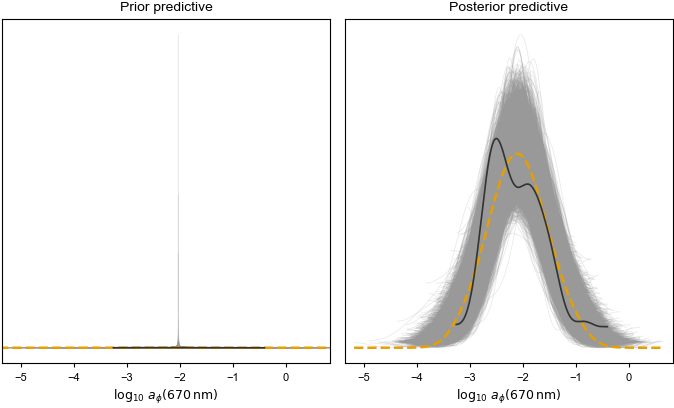

In [31]:
# SI Figure: Prior vs Posterior PPC (band 670); falls back to posterior-only if no prior saved
band = 670
f, axs=compare_ppc(
    idata_bart, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m2_compare_ppc_{band}.pdf"
)

##### b. Coverage and Uncertainty Calibration
###### - Coverage

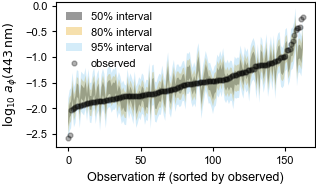

In [32]:
# SI Figure: HDI ribbons vs observed (band 443)
band=443
f, ax = plot_regression_hdi(
    idata_lin, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_bart_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /f'm2_hdi_{band}.png', )

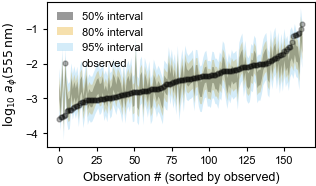

In [ ]:
# SI Figure: HDI ribbons vs observed (band 555)
band=555
f, ax = plot_regression_hdi(
    idata_lin, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_bart_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /f'm2_hdi_{band}.png', )

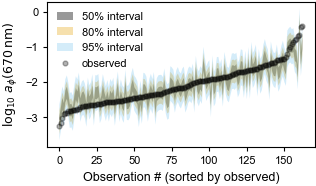

In [34]:
# SI Figure: HDI ribbons vs observed (band 670)
band=670
f, ax = plot_regression_hdi(
    idata_lin, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_bart_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /f'm2_hdi_{band}.png', )

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hd

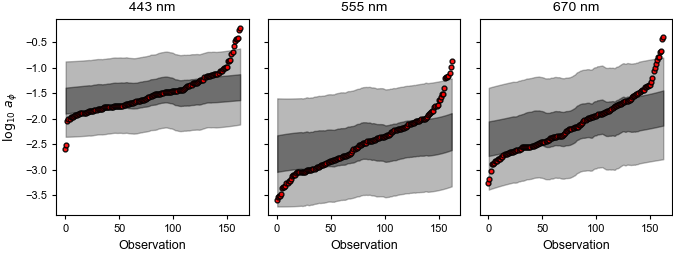

In [35]:
bands = [443, 555, 670]
fig, axes = pp.subplots(1, len(bands), figsize=(7.0, 7.0*0.4), sharey=True)

stats_list = []
for i, (ax_i, b) in enumerate(zip(axes, bands)):
    df_b = plot_ppc_hdi_band_multi(
        idata=idata_bart, band=b, hdi_probs=(0.95, 0.50),
        sort_by="observed", ax=ax_i  # <- draw into existing axes
    )
    stats_list.append(df_b)
    ax_i.set_title(f"{b} nm")  # optional; your call
    if i > 0: ax_i.set_ylabel('')  # only leftmost panel
fig.tight_layout()
save_pnas(fig, "figs/si/figS_m2_ppc_multi")
fig.savefig(DIR['figs'] / 'portfolio' /'m2_ppc_multi.png', )
stats_all_bart = pd.concat(stats_list, ignore_index=True)  # table-ready


In [25]:
stats_all_bart

,band,hdi_prob,n_obs,max_width_log,median_width_log,p90_width_log,max_factor,median_factor,p90_factor,factor_base
0,443,0.95,163,1.529108,1.483285,1.505923,33.814916,30.428826,32.057037,10.0
1,555,0.95,163,2.189086,2.117966,2.156645,154.556043,131.209710,143.431549,10.0
2,670,0.95,163,2.078184,1.984449,2.025423,119.724811,96.482605,106.028658,10.0


<u>**Predictive uncertainty by band (95% posterior predictive HDI; n = 163 per band)**</u>

These summaries report the **vertical span** of the posterior predictive highest-density interval (HDI) for each observation, in **log10 units** (widths) and as **multiplicative factors** (×). Because these are **posterior predictive** intervals, they combine both mean-function and residual uncertainty.

* 443 nm
  - **Median span:** 1.483 log10 → **×30.43**
  - **P90 span:** 1.506 log10 → **×32.06**
  - **Maximum span:** 1.529 log10 → **×33.81**

*Interpretation:* Typical uncertainty is ~30× (about 1.5 orders of magnitude).

* 555 nm
  - **Median span:** 2.118 log10 → **×131.21**
  - **P90 span:** 2.157 log10 → **×143.43**
  - **Maximum span:** 2.189 log10 → **×154.56**

*Interpretation:* Uncertainty is **very large** here—~131× on typical observations (a bit over **two orders of magnitude**).

* 670 nm
  - **Median span:** 1.984 log10 → **×96.48**
  - **P90 span:** 2.025 log10 → **×106.03**
  - **Maximum span:** 2.078 log10 → **×119.72**

*Interpretation:* Typical uncertainty is just under **two orders of magnitude** (~96×), with the widest envelopes ~120×.

**Cross-band takeaway.** Predictive uncertainty is **lowest at 443 nm** (~30×), **highest at 555 nm** (~131×), and **intermediate at 670 nm** (~96×), indicating substantially greater uncertainty in the green and red bands relative to the blue band.


In [37]:
# (Optional) SI Table: Coverage per band
cov_lin = posterior_coverage(idata_bart, var="likelihood")
cov_lin.to_csv(DIR["results"]/ "coverage_bart_diag.csv", index=False)
cov_lin.round(2)

,interval,band,coverage,nominal
0,95%,443,0.94,0.95
1,95%,555,0.95,0.95
2,95%,670,0.97,0.95
3,80%,443,0.91,0.80
4,80%,555,0.90,0.80
5,80%,670,0.88,0.80
6,50%,443,0.62,0.50
7,50%,555,0.60,0.50
8,50%,670,0.55,0.50


Coverage table suggest that the BART model is somewhat over-dispersed at all three bands, and all nominal  coverage levels (50/80/95%) are exceeded. This is consistent with the LOO-PIT plots, which show a concave,  ∩-shape (overdispersion) at all three bands.

###### - PPC + LOO-PIT

In [ ]:
with m_bart:
    try:
        _ = pm.compute_log_likelihood(idata_bart, extend_inferencedata=True)
    except ValueError:
        pass

In [51]:
loo_results = az.loo(idata_bart)
print(loo_results)

Computed from 8000 posterior samples and 489 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -327.71    20.43
p_loo       68.96        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      489  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [52]:
loo = az.loo(idata_bart, pointwise=True)
k_values = loo.pareto_k.values
influential_idx = (k_values > 0.7).nonzero()[0]
print("Influential observations:", influential_idx)

Influential observations: []


In [ ]:
idx, k, loo = find_influential_observations(
    idatas["BART (diag)"], threshold=0.7,
    save_csv=DIR["results"] / "loo_pareto_k_bart.csv"
)
print("Influential observations:", idx.tolist())

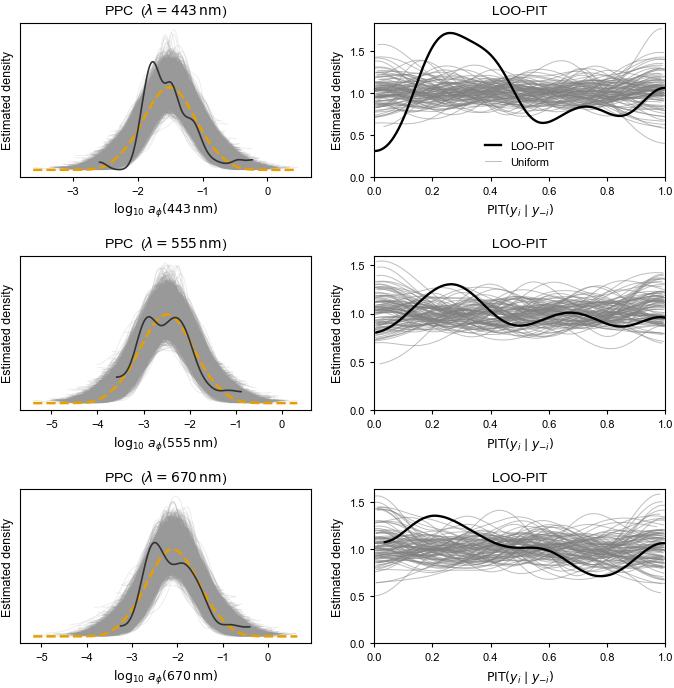

In [35]:
# All three bands in one 3×2 figure
f, axs = plot_ppc_pit_grid(
    idata_bart, var="likelihood",
    out=DIR["figs"]/ "si"/ "figS_ppc_pit_grid_bart_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /'m2_ppc_pit_grid.png', )

###### - LOO-PIT quality assessment via Pareto-k influential observations

In [38]:
infl_idx, k_values, loo_result = find_influential_observations(idata_bart)
"Influential Values detected" if len(infl_idx) else "No overly influential values to undermine PSIS-LOO"

'No overly influential values to undermine PSIS-LOO'

##### 7) Save Inference Data object

In [ ]:
save_idata(idata_bart, DIR["idata"], "bart_diag")

---
### Model 3 — Hierarchical linear mean with diagonal $\Sigma$ (partial pooling)

#### 1) Model specification (log-domain).**  
- Linear mean with **partial pooling** on intercepts/slopes (uncentered); independent residuals (diagonal $\Sigma$).  
- Observed variable name: `likelihood`.  
**Result notes:** [hyperprior settings; rationale → ______]


In [57]:
# Hierarchical linear model with uncentered parameterization
with pm.Model(coords=coords) as m_hier_lin: 
    X_data = pm.Data('log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y, dims=['obs_idx', 'λ_aφ'])
    α_μ = pm.Normal('α_μ', 0, 2)
    β_μ = pm.Normal('β_μ', 0, 2)
    α_σ = pm.HalfNormal('α_σ', 1)
    β_σ = pm.HalfNormal('β_σ', 1)

    α_center = pm.Normal('α_center', 0, 1, dims='λ_aφ')
    β_center = pm.Normal('β_center', 0, 1, dims=['λ_toa', 'λ_aφ'])
    α = pm.Deterministic('α', α_center * α_σ + α_μ, dims='λ_aφ')
    β = pm.Deterministic('β', β_center * β_σ + β_μ, dims=['λ_toa', 'λ_aφ'])
    μ = α + X_data @ β
    σ = pm.Exponential('σ', 1, dims='λ_aφ')
    likelihood = pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])

#### 2) Model DAG visualization  
- Sanity-check hierarchical structure and dims.  


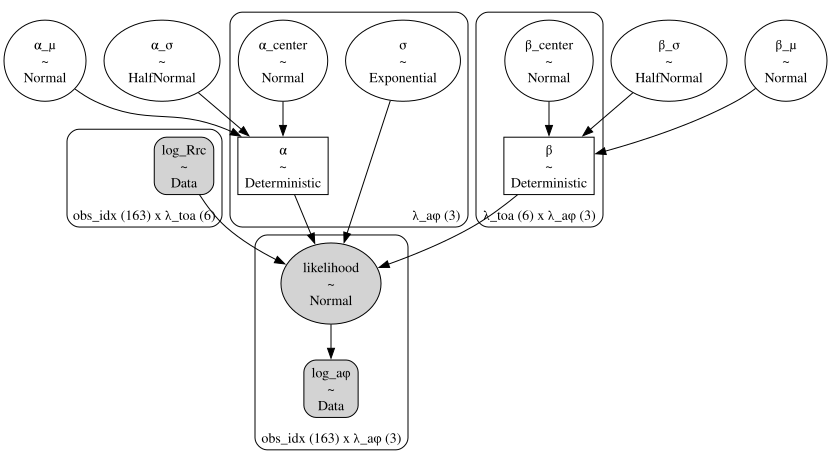

In [58]:
g3 = m_hier_lin.to_graphviz()
g3

In [59]:
g3.render("m3_bart_dag", directory=str(DIR["figs"]/ "si"), format="pdf", cleanup=True)
g3.render("m3_dag", directory=str(DIR['figs'] / 'portfolio'), format='png', cleanup=True)

'/Users/erdemkarakoylu/projex/bayesian_toa_2_iop/figs/portfolio/m3_dag.png'

In [40]:
save_model_dag(m_hier_lin, DIR["figs"]/ "si" / "figS_m3_dag.pdf", width="two")
save_model_dag(m_hier_lin, DIR['figs'] / 'portfolio' / 'm3_dag.png', format='png', width="two")

#### 3) Prior predictive check (gate)
- Visualize prior predictive; confirm plausibility.  

In [ ]:
with m_hier_lin:
    idata_hier = pm.sample_prior_predictive()

Sampling: [likelihood, α_center, α_μ, α_σ, β_center, β_μ, β_σ, σ]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α_μ, β_μ, α_σ, β_σ, α_center, β_center, σ]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 264 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [likelihood]


Output()

Output()

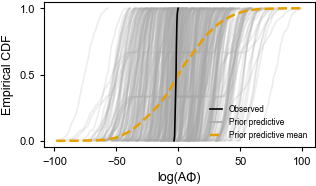

In [44]:
fig, ax = fig_ax(width="one", aspect=0.62)
az.plot_ppc(
    idata_hier, group='prior', kind='cumulative', 
    colors=PPC_COLORS, observed=True, ax=ax)

ax.set_xlabel('log(AΦ)')
ax.set_ylabel('Empirical CDF')
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_m3_prior_ppc.pdf")

The model might benefit from tighter priors. We'll see in the posterior predictive checks if this is the case.

#### 4) Posterior sampling (NUTS)


In [ ]:
with m_hier_lin:
        idata_hier.extend(
                pm.sample(chains=4, draws=2000, tune=2000,
                nuts_sampler_kwargs=dict(target_accept=0.95, max_treedepth=15)
                )
        )

#### 5) Sampling diagnostics

##### a. Summary statistics


In [45]:
summ = az.summary(idata_hier)
summ

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α_μ,-3.015,0.633,-4.234,-1.869,0.030,0.027,446.0,732.0,1.01
β_μ,-0.123,0.640,-1.310,1.109,0.043,0.023,219.0,395.0,1.01
α_center[443],0.736,0.720,-0.570,2.103,0.032,0.017,505.0,727.0,1.01
α_center[555],-0.411,0.586,-1.508,0.688,0.025,0.012,536.0,1322.0,1.01
α_center[670],-1.107,0.625,-2.363,0.006,0.027,0.012,513.0,1146.0,1.01
"β_center[412, 443]",1.066,0.372,0.363,1.747,0.018,0.008,443.0,1103.0,1.01
"β_center[412, 555]",0.773,0.448,-0.074,1.611,0.021,0.009,470.0,1348.0,1.01
"β_center[412, 670]",0.703,0.393,-0.039,1.428,0.018,0.008,487.0,1115.0,1.01
"β_center[443, 443]",-1.304,0.568,-2.407,-0.264,0.022,0.011,642.0,1544.0,1.01
"β_center[443, 555]",-0.988,0.697,-2.172,0.419,0.027,0.012,645.0,1672.0,1.01


r-hat is mostly 1.00 or 1.01. ESS  mostly OK.

In [46]:
summ["rMCSE_mean"] = summ["mcse_mean"] / summ["sd"]
summ["rMCSE_sd"]   = summ["mcse_sd"]   / summ["sd"]
summ[["rMCSE_mean","rMCSE_sd","ess_bulk","ess_tail","r_hat"]].describe()

,rMCSE_mean,rMCSE_sd,ess_bulk,ess_tail,r_hat
count,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.034444,0.017454,1339.265306,2103.489796,1.005306
std,0.015610,0.007863,1652.572399,1419.409166,0.005042
min,0.000000,0.000000,219.000000,395.000000,1.000000
25%,0.029341,0.013575,513.000000,1146.000000,1.000000
50%,0.034976,0.016760,819.000000,1826.000000,1.010000
75%,0.043200,0.020478,1156.000000,2338.000000,1.010000
max,0.067187,0.042654,8043.000000,6912.000000,1.010000


Above looks OK.

##### b. Energy plots 

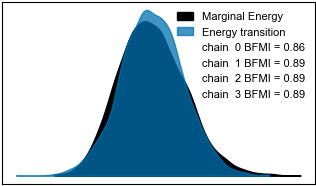

In [47]:
fig, ax = fig_ax()
az.plot_energy(idata_hier, ax=ax)
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_m3_energy.pdf")

Energy plots look pretty good. Good overlap & high BFMI.
##### c. Trace plots

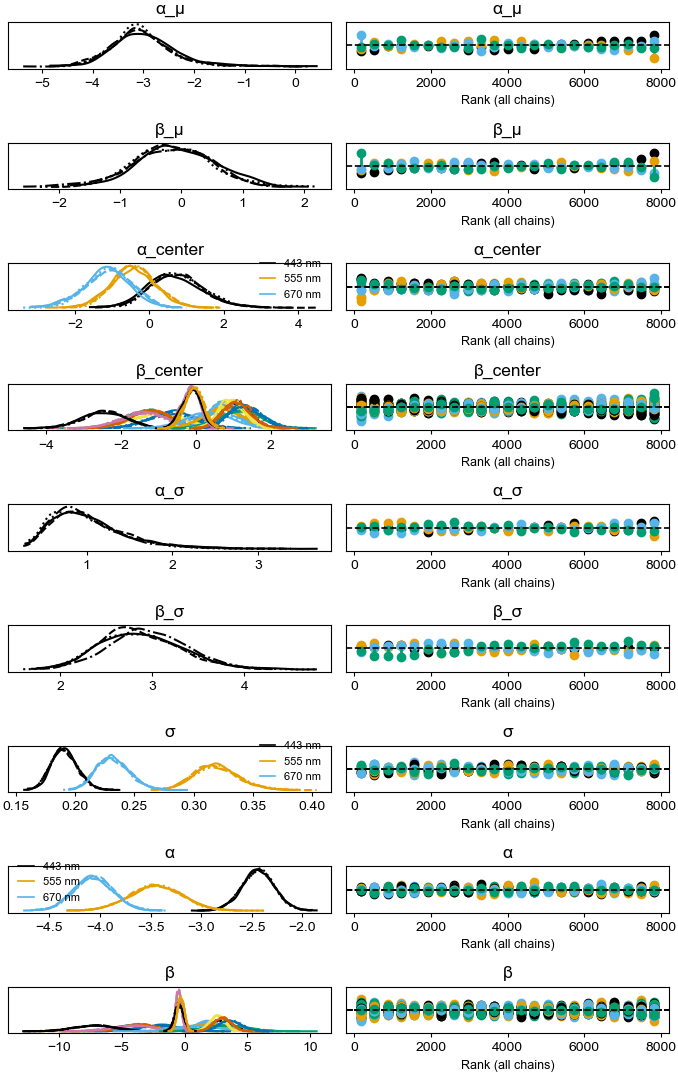

In [59]:
# Trace (compact) for a small var set — SI only
axs = az.plot_trace(
    idata_hier, compact=True, kind="rank_vlines",
    figsize=(7.0, 11.0), 
    )
axs[2, 0].legend(handles=legend_handles)
axs[6, 0].legend(handles=legend_handles)
axs[7, 0].legend(handles=legend_handles)

f = pp.gcf()
f.tight_layout()
#f.savefig(DIR["figs"]/"si"/"figS_m2_trace.pdf"); 

#### 6) Posterior predictive checks & log-likelihood

##### a. Posterior Predictive Checks

###### - 3-way posterior predictive check


In [ ]:
with m_hier_lin:
    pm.sample_posterior_predictive(idata_hier_lin, extend_inferencedata=True)

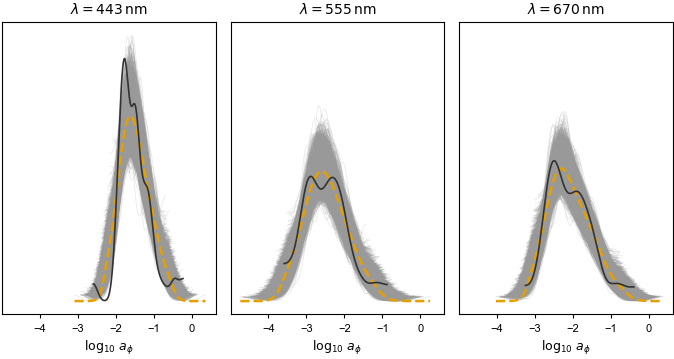

In [60]:
f, axs = plot_3_way_ppc(
    idata=idata_hier, var="likelihood",
    out=DIR["figs"] / "si" / f"figS_m3_ppc.pdf"
    )
f.savefig(DIR['figs'] / 'portfolio' /'m3_ppc.png')

###### - Prior vs posterior predictive

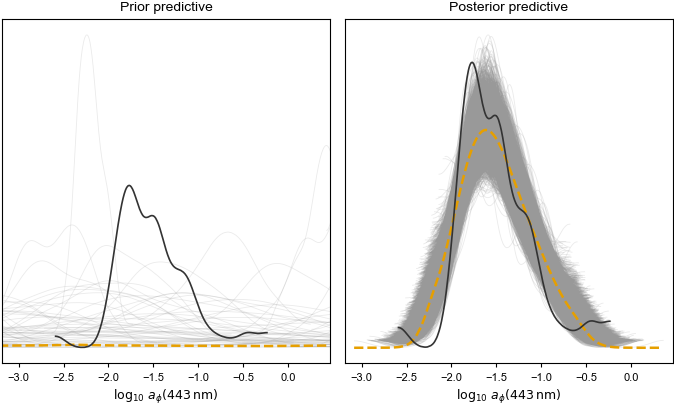

In [61]:
band = 443
f, axs=compare_ppc(
    idata_hier, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m3_compare_ppc_{band}.pdf"
)

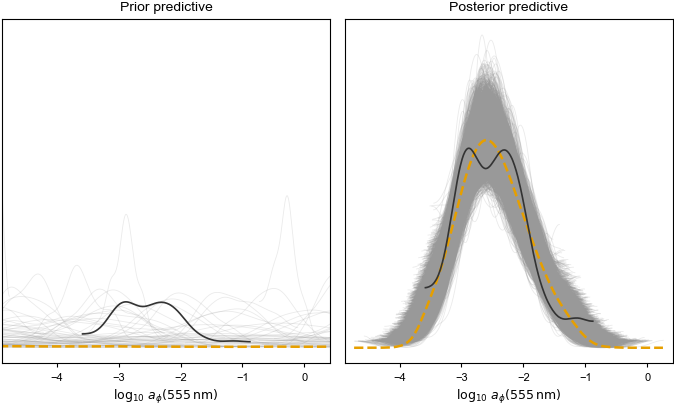

In [62]:
band = 555
f, axs=compare_ppc(
    idata_hier, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m3_compare_ppc_{band}.pdf"
)

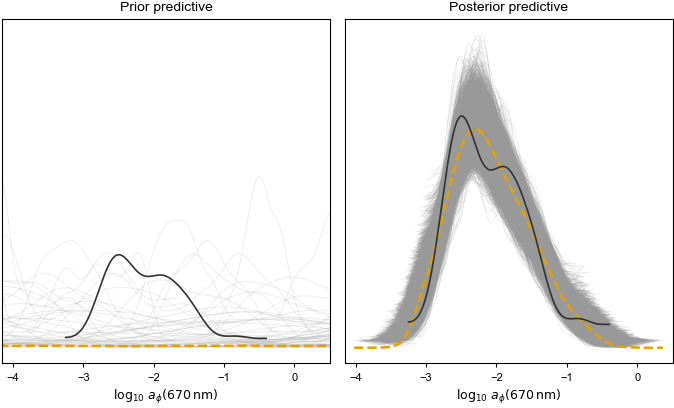

In [63]:
band = 670
f, axs=compare_ppc(
    idata_hier, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m3compare_ppc_{band}.pdf"
)

In all cases prior predictive is very wide, suggesting we can save resources on sampling with some tighter priors, esp. in view of the small number of observatoins. Posterior predictive is much tighter and captures the observed distribution with some issues including some overdipsersion at all bands, some possible bias at 443nm and 555 (mostly the tail end), and some missed structure around the peaks.
There might not be much to do about the latter, given the current Gaussian likelihood aasumption implemented in the model. 

##### b. Coverage and Uncertainty Calibration
###### - Coverage

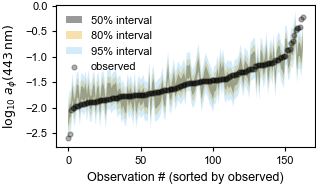

In [64]:
# SI Figure: HDI ribbons vs observed (band 443)
band=443
f, ax = plot_regression_hdi(
    idata_hier, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_bart_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /f'm3_hdi_{band}.png', )

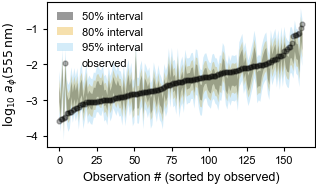

In [65]:
# SI Figure: HDI ribbons vs observed (band 443)
band=555
f, ax = plot_regression_hdi(
    idata_hier, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_bart_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /f'm3_hdi_{band}.png', )

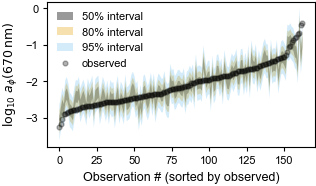

In [66]:
# SI Figure: HDI ribbons vs observed (band 443)
band=670
f, ax = plot_regression_hdi(
    idata_hier, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_bart_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /f'm3_hdi_{band}.png', )

In [136]:
# (Optional) SI Table: Coverage per band
cov_lin = posterior_coverage(idata_hier, var="likelihood")
cov_lin.to_csv(DIR["results"]/ "coverage_hier_diag.csv", index=False)
cov_lin.round(2)

,interval,band,coverage,nominal
0,95%,443,0.96,0.95
1,95%,555,0.96,0.95
2,95%,670,0.96,0.95
3,80%,443,0.87,0.80
4,80%,555,0.87,0.80
5,80%,670,0.85,0.80
6,50%,443,0.52,0.50
7,50%,555,0.55,0.50
8,50%,670,0.56,0.50


/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hd

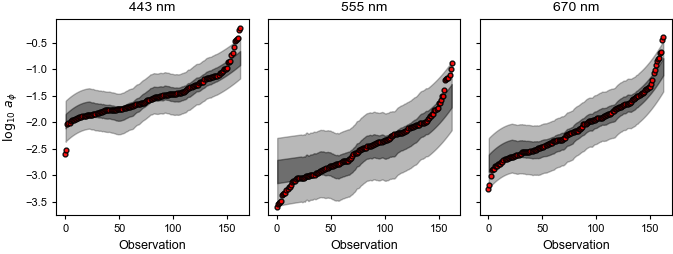

In [34]:
bands = [443, 555, 670]
fig, axes = pp.subplots(1, len(bands), figsize=(7.0, 7.0*0.4), sharey=True)

stats_list = []
for i, (ax_i, b) in enumerate(zip(axes, bands)):
    df_b = plot_ppc_hdi_band_multi(
        idata=idata_hier, band=b, hdi_probs=(0.95, 0.50),
        sort_by="observed", ax=ax_i  # <- draw into existing axes
    )
    stats_list.append(df_b)
    ax_i.set_title(f"{b} nm")  # optional; your call
    if i > 0: ax_i.set_ylabel('')  # only leftmost panel
fig.tight_layout()
save_pnas(fig, "figs/si/figS_m3_ppc_multi")
fig.savefig(DIR['figs'] / 'portfolio' /'m3_ppc_multi.png', )
stats_all_hier = pd.concat(stats_list, ignore_index=True)  # table-ready

In [28]:
stats_all_hier

,band,hdi_prob,n_obs,max_width_log,median_width_log,p90_width_log,max_factor,median_factor,p90_factor,factor_base
0,443,0.95,163,0.806843,0.763705,0.779600,6.409777,5.803698,6.020050,10.0
1,555,0.95,163,1.338419,1.273823,1.296769,21.798132,18.785526,19.804722,10.0
2,670,0.95,163,0.992180,0.927879,0.947963,9.821555,8.469911,8.870798,10.0


###### - LOO-PIT quality assessment via Pareto-k influential observations

In [ ]:
with m_bart:
    try:
        _ = pm.compute_log_likelihood(idata_hier, extend_inferencedata=True)
    except ValueError:
        pass

In [69]:
loo_results = az.loo(idata_hier)
print(loo_results)

Computed from 8000 posterior samples and 489 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -11.05    23.26
p_loo       24.46        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      489  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



No unduly influential observations per Pareto-k.

Some overdispersion at all bands under 95% nominal coverage.

###### - PPC + LOO-PIT

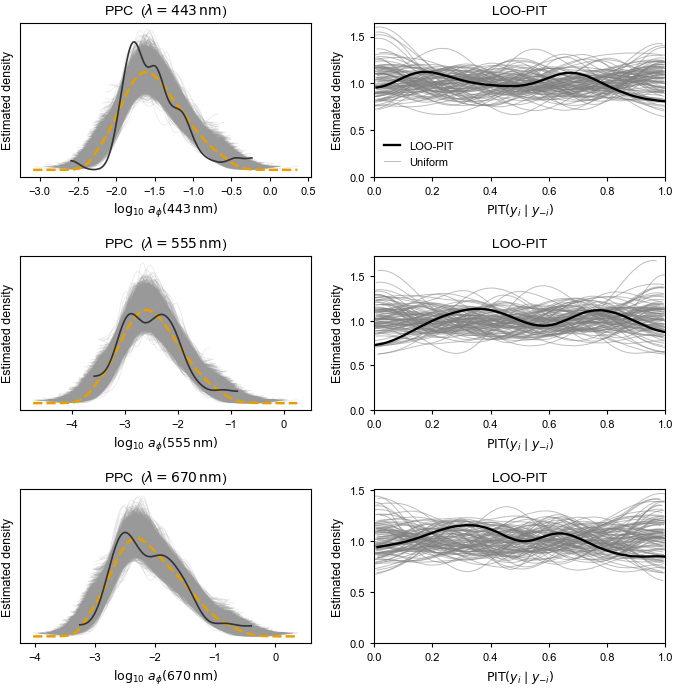

In [70]:
# All three bands in one 3×2 figure
f, axs = plot_ppc_pit_grid(
    idata_hier, var="likelihood",
    out=DIR["figs"]/ "si"/ "figS_ppc_pit_grid_hier_diag.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /'m3_ppc_pit_grid.png', )

No major issues expected on predicting future data, per LOO-PIT.

#### 7) Save Inference Data


## Model Comparisons - Diagonal Σ models

<u>**Cross-model takeaway (95% posterior predictive HDIs; n = 163 per band)**</u>

Across the three models, **BART yields substantially wider predictive intervals** than the two linear/MVN variants at every band, while the **green band (555 nm)** is consistently the most uncertain for all models.

* **Magnitude of predictive span (median, × factors)**
  - **443 nm:** Linear ≈ **×6.1**, Alt-Linear ≈ **×5.8**, **BART ≈ ×30.4**  
    *BART ≈ 5× wider than linear models.*
  - **555 nm:** Linear ≈ **×20.9**, Alt-Linear ≈ **×18.8**, **BART ≈ ×131.2**  
    *BART ≈ 6–7× wider; all models largest at 555 nm.*
  - **670 nm:** Linear ≈ **×9.7**, Alt-Linear ≈ **×8.5**, **BART ≈ ×96.5**  
    *BART ≈ 10× wider; red band sits near one order of magnitude for linear models.*

**Interpretation.**  
- The two linear/MVN models produce **comparable** predictive uncertainty profiles (blue ≈ lowest, green ≈ highest, red ≈ intermediate).  
- **BART’s predictive envelopes are an order of magnitude (or more) larger**, suggesting either (i) **over-dispersion** in its posterior predictive (e.g., larger residual variance/leaf noise), (ii) **conservative priors or hyperparameters** (e.g., tree depth/number, variance priors) that inflate predictive variance, or (iii) **mismatch in likelihood/noise model** relative to the linear setups.

**Next checks (model diagnostics).**  
- Compare **coverage vs. nominal** (does 95% HDI ≈ 95% empirical coverage?).  
- Inspect **LOO-PIT** / calibration diagnostics for under/over-dispersion.  
- Consider **CRPS** (continuous ranked probability score) to balance **sharpness** and **calibration** across models.  
- For BART, review **tree priors/hyperparameters** (num_trees, α/β), **noise priors**, and potential **heteroskedastic** or **band-specific** variance structures to reduce unnecessary predictive spread while preserving calibration.


In [517]:
save_idata(idata_hier_lin, DIR["idata"], "hier_lin_diag")

PosixPath('/Users/erdemkarakoylu/projex/bayesian_toa_2_iop/inferencedata/hier_lin_diag.nc')

In [71]:
model_comparison = az.compare(
    {
        'Linear': idata_lin,
        'BART': idata_bart, 
        'Hierarchical Linear': idata_hier  
    },
    ic='loo', method='BB-pseudo-BMA')

In [72]:
model_comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Hierarchical Linear,0,-11.045478,24.456515,0.000000,9.995861e-01,23.668427,0.000000,False,log
Linear,1,-30.680171,19.208789,19.634693,4.138985e-04,22.397075,4.840338,False,log
BART,2,-327.712058,68.960161,316.666580,5.475873e-114,20.304598,16.762460,False,log


Text(0.5, 0, 'Expected Log Predictive Density (ELPD)')

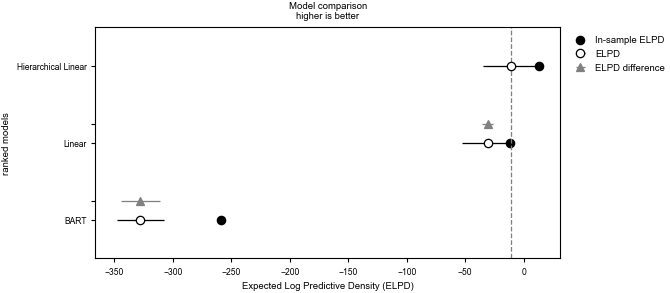

In [ ]:
ax = az.plot_compare(model_comparison, plot_ic_diff=True, insample_dev=True, legend=True)
ax.set_title("Model Comparison (higher is better)")
ax.set_xlabel("Expected Log Predictive Density (ELPD)")

Both linear models, in spite of high input and output collinearity, are expected to be significantly better able to predict future data than the BART model, which is somewhat surprising since tree-based models are relatively robust against multicollinearity. One reason for the observed lack of performance is perhaps the small sample size (N=163) relative to the complexity of the BART model. While we explored a range of hyperparameter settings (not shown) designed to make the BART model more complex (e.g. doubling the number of estimators from 10 to 20) we didn't push it too far to avoid overfitting, given the small sample size.

While the best model is the Hierarchical Linear, the gain over the simple linear model is small, within ELPD SE. 

As mentioned above on lingering issue is the multicollinearity of both inputs and outputs. To investigate whether any or all models are adversely affected by this, I proceed to build diagnostics from residual draws  and do a correlation analysis
Given the added complexity and sampling time of the hierarchical model, I proceed with the simple linear model for the full-covariance MVN.

## B — Assessing Residual Covariance and the Rationale for the MVN Model

Below we evaluate whether a model with *independent likelihoods* (one per wavelength) leaves unexplained covariance between residuals.  

We first draw residuals across all posterior samples, reflecting what the model predicts vs. what was observed. Then, for each posterior draw, we compute the residual correlation matrix — quantifying how prediction errors at one wavelength (e.g., 443 nm) co-vary with those at another (e.g., 490 nm or 555 nm).  

If the residuals are truly independent, off-diagonal correlations should cluster around zero. However, if consistent positive or negative correlations appear, it suggests that information shared across wavelengths remains unmodeled.  

This matters because ocean-color signals at nearby bands are physically and optically correlated — ignoring that correlation (as in independent Gaussian likelihoods) can lead to underestimation of uncertainty and inefficient use of data.  In this is the case, a multivariate normal (MVN) likelihood with a full covariance matrix can better capture the joint structure of errors across bands.

In short, this analysis checks whether the independent model “leaves covariance on the table.” If it does, adopting an MVN likelihood is warranted — not to change the mean prediction, but to more faithfully represent the joint uncertainty structure across wavelengths.


In [ ]:
# Build residual draws  that exposes posterior α, β (or μ)
def residual_draws_from_linear(idata, X, var="likelihood"):
    # prefer μ if saved; else reconstruct from α, β
    if "μ" in idata.posterior:
        mu = idata.posterior["μ"].stack(sample=("chain","draw")).transpose("sample","obs_idx","λ_aφ").values
    else:
        α = idata.posterior["α"].stack(sample=("chain","draw")).transpose("sample","λ_aφ").values      # (S,K)
        β = idata.posterior["β"].stack(sample=("chain","draw")).transpose("sample","λ_toa","λ_aφ").values  # (S,6,K)
        mu = α[:, None, :] + np.einsum("ij,spj->spi", X, β)  # (S,N,K)

    y_obs = idata.observed_data[var].values  # (N,K)
    resid = y_obs[None, :, :] - mu           # (S,N,K)
    return resid



# Correlation analysis plot (fix labels to 443/555/670)

# def corr_matrix(x):  # x: (N,K)
#     return np.corrcoef(x.T)

# def plot_corr_analysis(resid):
#     corrs = np.array([corr_matrix(r) for r in resid])  # (S,K,K)
#     band_labels = ["aph443","aph555","aph670"]  # K=3 here
#     pairs = list(combinations(range(corrs.shape[1]), 2))
#     ncols = min(3, len(pairs)); nrows = int(np.ceil(len(pairs)/ncols))
#     fig, axes = pp.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows)); axes = np.atleast_1d(axes).ravel()
#     for ax, (i, j) in zip(axes, pairs):
#         rho_ij = corrs[:, i, j]
#         az.plot_posterior(rho_ij, hdi_prob=0.9, ref_val=0.0, ax=ax, rope=[-0.05, 0.05])
#         ax.set_title(f"corr(resid_{band_labels[i]}, resid_{band_labels[j]})")
#     for k in range(len(pairs), len(axes)): axes[k].axis("off")
#     fig.suptitle("Posterior distribution of residual correlations (90% HDI)", y=1.02)
#     pp.tight_layout()
#     return fig, axes

# fig_corr, _ = plot_corr_analysis(resid)
# save_pnas(fig_corr, DIR["figs"] / "si" / "figS_resid_correlation_hier_linear_diag.pdf")


In [ ]:
# Example: run on the linear model with diagonal covariance
resid_lin = residual_draws_from_linear(idata_lin, X, var="likelihood")  # (S,N,K)
S, N, K = resid_lin.shape

In [ ]:
# Example: run on the BART model with diagonal covariance
resid_bart = residual_draws_from_linear(idata_bart, X, var="likelihood")  # (S,N,K)
S, N, K = resid_bart.shape

In [ ]:
# Example: run on the hierarchical model with diagonal covariance
resid_hier_lin = residual_draws_from_linear(idata_hier_lin, X, var="likelihood")  # (S,N,K)
S, N, K = resid_hier_lin.shape

In [304]:
# y_obs: (n, K)
y_obs = idata_bart.observed_data["likelihood"].values
# posterior predictive: (chain, draw, n, K)
y_ppc = idata_bart.posterior_predictive["likelihood"].values
chains, draws, n, K = y_ppc.shape
S = chains * draws
y_ppc = y_ppc.reshape((S, n, K))

# residuals for each draw
resid_bart = y_obs[None, :, :] - y_ppc  # (S, n, K)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/2041707944.py:28: UserWarning: The figure layout has changed to tight
  pp.tight_layout()


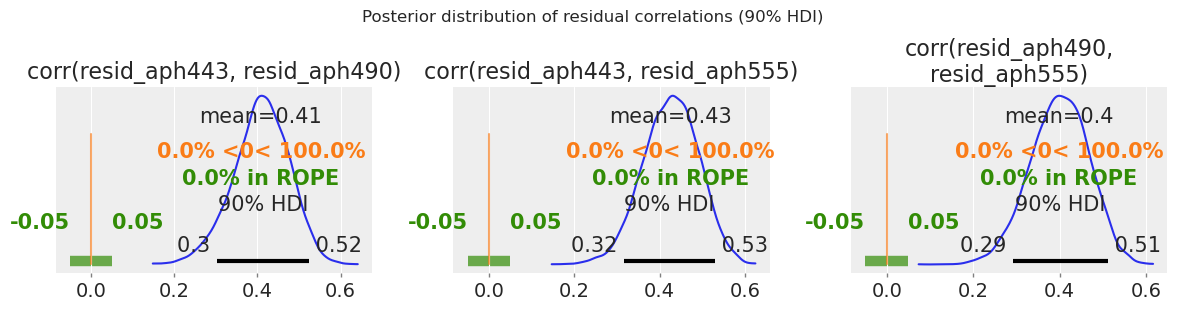

In [305]:
from itertools import combinations
# correlation matrices per draw (S, K, K)
def corr_matrix(x):  # x: (n, K)
    return np.corrcoef(x.T)

def plot_corr_analysis(resid):
    corrs = np.array([corr_matrix(r) for r in resid])

    band_labels = ["aph443","aph490","aph555"][:K]  # adjust labels if needed

    # Plot posterior for each off-diagonal correlation with HDIs and ref line at 0
    pairs = list(combinations(range(K), 2))
    ncols = min(3, len(pairs))
    nrows = int(np.ceil(len(pairs)/ncols))
    fig, axes = pp.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (i, j) in zip(axes, pairs):
        rho_ij = corrs[:, i, j]  # (S,)
        az.plot_posterior(rho_ij, hdi_prob=0.9, ref_val=0.0, ax=ax, rope=[-0.05, 0.05])
        ax.set_title(f"corr(resid_{band_labels[i]}, resid_{band_labels[j]})")

    # Hide any unused axes
    for k in range(len(pairs), len(axes)):
        axes[k].axis("off")

    fig.suptitle("Posterior distribution of residual correlations (90% HDI)", y=1.02)
    pp.tight_layout()

plot_corr_analysis(resid_bart)

In [89]:
def residual_draws_from_linear(idata, X, var="likelihood"):
    """
    Compute posterior residual draws from a fitted linear model.

    This function reconstructs or retrieves the model-predicted means (μ) 
    from posterior samples, then computes residuals (observed - predicted)
    across all posterior draws. If μ is not explicitly saved in the model,
    it is reconstructed from posterior samples of intercepts (α) and slopes (β).

    Parameters
    ----------
    idata : arviz.InferenceData
        Inference data object containing posterior samples and observed data.
    X : np.ndarray
        Predictor matrix of shape (N, P), where N is the number of observations 
        and P is the number of predictors.
    var : str, optional
        Name of the observed variable in the `idata.observed_data` group.
        Defaults to "likelihood".

    Returns
    -------
    resid : np.ndarray
        Residual draws of shape (S, N, K), where:
        - S = total number of posterior samples (chains × draws)
        - N = number of observations
        - K = number of response dimensions (e.g., wavelengths)
    """
    if "μ" in idata.posterior:
        mu = idata.posterior["μ"].stack(sample=("chain","draw")).transpose("sample","obs_idx","λ_aφ").values
    else:
        α = idata.posterior["α"].stack(sample=("chain","draw")).transpose("sample","λ_aφ").values      # (S,K)
        β = idata.posterior["β"].stack(sample=("chain","draw")).transpose("sample","λ_toa","λ_aφ").values  # (S,6,K)
        mu = α[:, None, :] + np.einsum("ij,spj->spi", X, β)  # (S,N,K)

    y_obs = idata.observed_data[var].values  # (N,K)
    resid = y_obs[None, :, :] - mu           # (S,N,K)
    return resid


def corr_matrix(x):
    """
    Compute the correlation matrix of multivariate samples.

    Parameters
    ----------
    x : np.ndarray
        Array of shape (N, K), where N is the number of samples 
        and K is the number of variables.

    Returns
    -------
    corr : np.ndarray
        Correlation matrix of shape (K, K).
    """
    return np.corrcoef(x.T)


def plot_corr_analysis(resid, hdi_prob=0.94, rope_fraction=0.05):
    """
    Plot posterior distributions of residual correlations.

    Computes a correlation matrix for each posterior draw of residuals,
    then plots the marginal posterior distribution of each off-diagonal 
    correlation coefficient with 90% HDIs and a reference line at zero.

    Parameters
    ----------
    resid : np.ndarray
        Residual draws of shape (S, N, K) from `residual_draws_from_linear`.

    Returns
    -------
    None
        Displays a figure of posterior residual correlations across wavelengths.
    """
    rope = [-rope_fraction, rope_fraction]
    corrs = np.array([corr_matrix(r) for r in resid])
    band_labels = ["aph443","aph555","aph670"][:K]
    pairs = list(combinations(range(K), 2))
    ncols = min(3, len(pairs))
    nrows = int(np.ceil(len(pairs)/ncols))
    fig, axes = pp.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (i, j) in zip(axes, pairs):
        rho_ij = corrs[:, i, j]
        az.plot_posterior(rho_ij, hdi_prob=hdi_prob, ref_val=0.0, ax=ax, rope=rope)
        ax.set_title(f"corr(resid_{band_labels[i]}, resid_{band_labels[j]})")

    for k in range(len(pairs), len(axes)):
        axes[k].axis("off")

    fig.suptitle("Posterior distribution of residual correlations", y=1.02)
    pp.tight_layout()


### 1. Linear model (Model 1) Residual correlation analysis

#### a. Extract residuals from posterior predictive draws

In [90]:
# y_obs: (n, K)
y_obs = idata_lin.observed_data["likelihood"].values
# posterior predictive: (chain, draw, n, K)
y_ppc = idata_lin.posterior_predictive["likelihood"].values
chains, draws, n, K = y_ppc.shape
S = chains * draws
y_ppc = y_ppc.reshape((S, n, K))

# residuals for each draw
resid = y_obs[None, :, :] - y_ppc  # (S, n, K)

#### b. Visualize residual correlations
We add an adjustable Region of Practical Equivalence (ROPE) of ±0.05 to judge significance. For added robustness, we use the near full posterior, i.e. 99% HDI

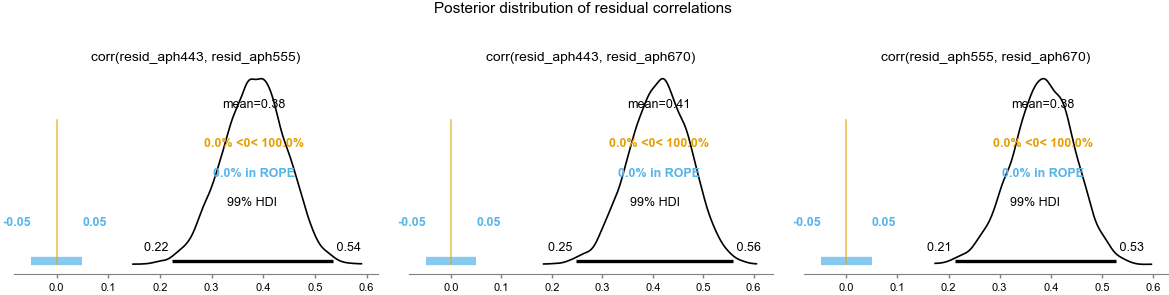

In [91]:
plot_corr_analysis(resid, hdi_prob=.99)
f = pp.gcf()
save_pnas(f, DIR["figs"] / "si" / "figS_resid_correlation_linear_diag.pdf")
f.savefig(DIR['figs'] / 'portfolio' /'mi_resid_corr.png', )

In all 3 cases, there is significant residual correlation between bands, as hinted by the posterior distributions.

### 2. BART model (Model 2) Residual correlation analysis
#### a. Extract residuals from posterior predictive draws

In [92]:
# y_obs: (n, K)
y_obs = idata_bart.observed_data["likelihood"].values
# posterior predictive: (chain, draw, n, K)
y_ppc = idata_bart.posterior_predictive["likelihood"].values
chains, draws, n, K = y_ppc.shape
S = chains * draws
y_ppc = y_ppc.reshape((S, n, K))

# residuals for each draw
resid = y_obs[None, :, :] - y_ppc  # (S, n, K)

#### b. Visualize residual correlations

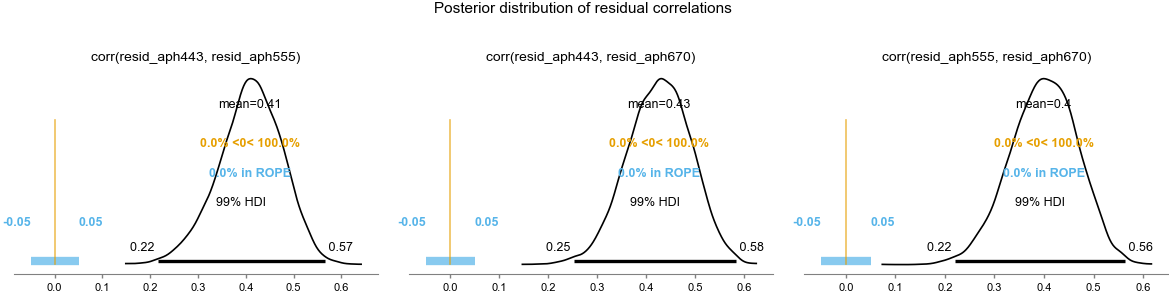

In [93]:
plot_corr_analysis(resid, hdi_prob=.99)
f = pp.gcf()
save_pnas(f, DIR["figs"] / "si" / "figS_resid_correlation_bart_diag.pdf")
f.savefig(DIR['figs'] / 'portfolio' /'m2_resid_corr.png', )

Again, in all 3 cases, there is significant residual correlation between bands, as hinted by the posterior distributions.

### 3. Hierarchical model (Model 3) Residual correlation analysis
#### a. Extract residuals from posterior predictive draws

In [94]:
# y_obs: (n, K)
y_obs = idata_hier.observed_data["likelihood"].values
# posterior predictive: (chain, draw, n, K)
y_ppc = idata_hier.posterior_predictive["likelihood"].values
chains, draws, n, K = y_ppc.shape
S = chains * draws
y_ppc = y_ppc.reshape((S, n, K))

# residuals for each draw
resid = y_obs[None, :, :] - y_ppc  # (S, n, K)

#### b. Visualize residual correlations

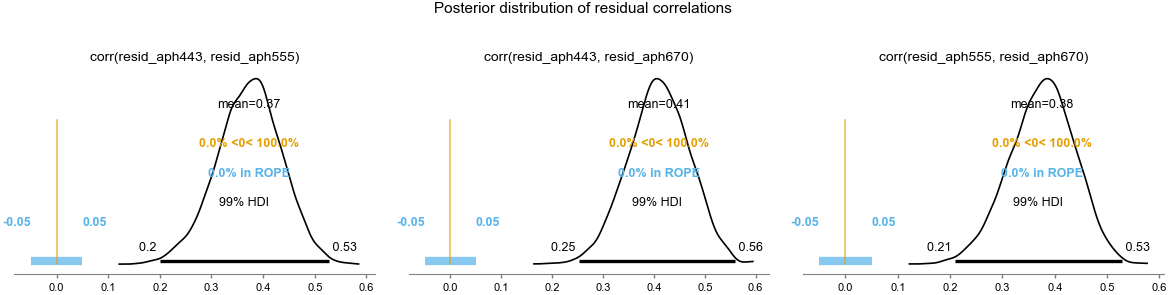

In [95]:
plot_corr_analysis(resid, hdi_prob=.99)
f = pp.gcf()
save_pnas(f, DIR["figs"] / "si" / "figS_resid_correlation_hier_lin_diag.pdf")
f.savefig(DIR['figs'] / 'portfolio' /'m3_resid_corr.png', )

In all cases that’s a clear signal: if all three residual cross-correlation posteriors have 0% mass inside even ±0.05 (even ±0.10), the independent-errors modes are misspecified. The principled next step is to model a joint residual covariance—Multivariate Normal(MVN) likelihood with an LKJ prior (SUR-style). We use the linear model for that, given its simplicity and the fact that it was within ELPD SE of the hierarchical model. The added complexity that the MVN structure will bring on top of the hierarchical model's own complexity is thus not justified.

---
## C — Covariance matters (full Σ)

### Understanding the Covariance Structure in the Multivariate Model

#### → Cholesky Factorization of Covariance Matrix with LKJ Prior

* Corresponds to this line in the model:
```python

packed_Lcov, R_corr, σ_resid = pm.LKJCholeskyCov(
        'L_parts', n=K, eta=2, # weakly informative prior
        sd_dist=pm.Exponential.dist(1.0),compute_corr=True )
```
* Goal: put a prior on a K×K covariance matrix via a correlation + scale decomposition.
* $n=K$: dimension of the residual vector (here, K=3 for aph at 443, 555, 670nm)
* $\eta=2.0$: LKJ concentration:
  * $\eta=1.0$ is uniform over correlation matrices
  * $\eta>1.0$ increasingly shrinks correlations toward zero
  * $eta=2-3$ mild shrinkage toward zero correlations
  * $\eta<1.0$ increasingly shrinks correlations toward -1 and +1
* `sd_dist=pm.Exponential.dist(1.0)`: prior on the K residual / marginal standard deviations (σ_resid)
  *  Swapable HalfNormal.dist(scale), HalfSutdentT.dist(scale) HalfCauchy.dist(scale), etc. depending on the desired tail behavior or scaling requirement of the data.
* `compute_corr=True` returns:
    * packed_Lcov: the K(K+1)/2 non-redundant elements of the lower-triangular Cholesky factor of the covariance matrix (L)
    * R_corr: the K×K correlation matrix
    * σ_resid: the K marginal standard deviations (the diagonal of the covariance matrix); a positive vector of length K

Intuition: This draws a random correlation matrix $R$ from the $LKJ(\eta)$ prior, then scales it by random standard deviations to get a random covariance matrix $\Sigma = diag(\sigma) R diag (\sigma)$. The Cholesky factorization (L) is computed internally and returned in packed form for computational efficiency.



#### → Build the Cholesky Factor (L)
* Corresponds to this line in the model:
```python
L = pm.Deterministic('L_chol', 
                         pt.diag(σ_resid) @ pt.linalg.cholesky(R_corr),
                         dims=('λ_aφ', 'λ_aφ'))
```
* Goal: construct the Cholesky factor (L) of the covariance matrix (Σ)
* `pt.diag(σ_resid)`: turns the length-K vector of standard deviations into a K×K diagonal matrix $D=diag(\sigma)$
* `pt.linalg.cholesky(R_corr)`: computes the (lower-triangular) Cholesky  $C$ of the correlation matrix $R$ such that $R = CC^T$
* The Matrix multiplication `@` product $L = DC$ is the Cholesky factor of the covariance matrix: 
$$LL^T =(DC)(DC)^T = DCC^TD = DRD =\Sigma$$
* Why build L this way? 
  * avoids having to unpack triangles directly
  * clear separation of scales (σ) and correlations (R)
  * easy to understand: covaraince = scales × correlations × scales
* L is saved to the trace for later inspection and posterior predictive checks
* dims=['λ_aφ', 'λ_aφ'] tages the two axes with output-band coordinate for clarity in plotting.
#### → Store implied covariance for sanity checks
* Corresponds to this line in the model:
```python
Σ = pm.Deterministic('Σ', L @ L.T, dims=('λ_aφ', 'λ_aφ'))
```
* Not needed for samplibg, but useful because...
* Confirms $\Sigma = LL^T$ as the covariance matrix
* Great for diagnostics (e.g. posterior heatmap of covariance, etc) 
#### → Store correlation matrix and standard deviations for diagnostics
* Corresponds to these lines in the model:
```python
pm.Deterministic('R_corr', R_corr, dims=('λ_aφ', 'λ_aφ'))
pm.Deterministic('σ_resid', σ_resid, dims='λ_aφ')
```
* Again Not needed for sampling, but useful 
* Allows direct plotting of residual correlations and residual standard deviations for each band without having to reconstruct from L or Σ.
#### → Use L in the Multivariate Normal Likelihood
* Corresponds to this line in the model:
```python
likelihood = pm.MvNormal(
        'likelihood', mu=μ, chol=L,
        observed=Y_data, dims=['obs_idx', 'λ_aφ']
        )
```
* The multivariate normal likelihood uses the Cholesky factor (L) to define the covariance structure of the residuals.


### Model 4 — Linear mean (flat) with full Σ(MVN; final model for main text)
#### 1) Model Code


In [39]:
# The coordinates dictionary requires some modification to differentiate between the two axes of the covariance matrix.
# ---  existing parsing ---
x_idx, x_names = X.columns.factorize()
y_idx, y_names = Y.columns.factorize()
λ      = [li.split('Rrc_')[-1] for li in x_names]   # predictor band labels
λ_aph  = [li.split('aph')[-1]   for li in y_names]  # output band labels

# sanity: make them plain Python lists (not Index) and ensure same order as data
λ      = list(λ)
λ_aph  = list(λ_aph)

# --- NEW: alias dims for square matrices over outputs ---
coords_mvn = {
    "obs_idx": X.index,     # rows
    "λ_toa":   λ,           # predictors (TOA bands)
    "λ_aφ":    λ_aph,       # outputs (aph bands)
    "λ_aφ_row": λ_aph,      # alias for matrix row dim over outputs
    "λ_aφ_col": λ_aph,      # alias for matrix col dim over outputs
}


In [40]:
with pm.Model(coords=coords_mvn) as m_lin_mvn: 
    # Data
    X_data = pm.Data('log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y, dims=['obs_idx', 'λ_aφ'])

    # Coefficients (shrinkage recomended if X is collinear)
    τ = pm.HalfNormal('τ', 1.0)
    α = pm.Normal('α', 0, 1, dims='λ_aφ')
    β = pm.Normal('β', 0, τ, dims=['λ_toa', 'λ_aφ'])

    # Mean
    μ = pm.Deterministic('μ', α + X_data @ β, dims=['obs_idx', 'λ_aφ'])

    # This is the part that changes.
    #    σ = pm.Exponential('σ', 1, dims='λ_aφ')
    #    likelihood = pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data)
    #  Residual covariance via LKJ prior (Cholesky factorization of covariance matrix)
    _, R_corr, σ_resid = pm.LKJCholeskyCov(
        'L_parts', n=len(λ_aph), eta=2, # weakly informative prior
        sd_dist=pm.HalfNormal.dist(1.0),compute_corr=True )
    L = pm.Deterministic('L_chol', 
                         pt.diag(σ_resid) @ pt.linalg.cholesky(R_corr),
                         dims=('λ_aφ_row', 'λ_aφ_col'))
    Σ = pm.Deterministic('Σ', L @ L.T, dims=('λ_aφ_row', 'λ_aφ_col'))
    pm.Deterministic('R_corr', R_corr, dims=('λ_aφ_row', 'λ_aφ_col'))
    pm.Deterministic('σ_resid', σ_resid, dims='λ_aφ')

    likelihood = pm.MvNormal(
        'likelihood', mu=μ, chol=L,
        observed=Y_data, dims=['obs_idx', 'λ_aφ']
        )
   

#### 2) Model DAG visualization
- Sanity-check Cholesky/covariance parameterization and dims.  

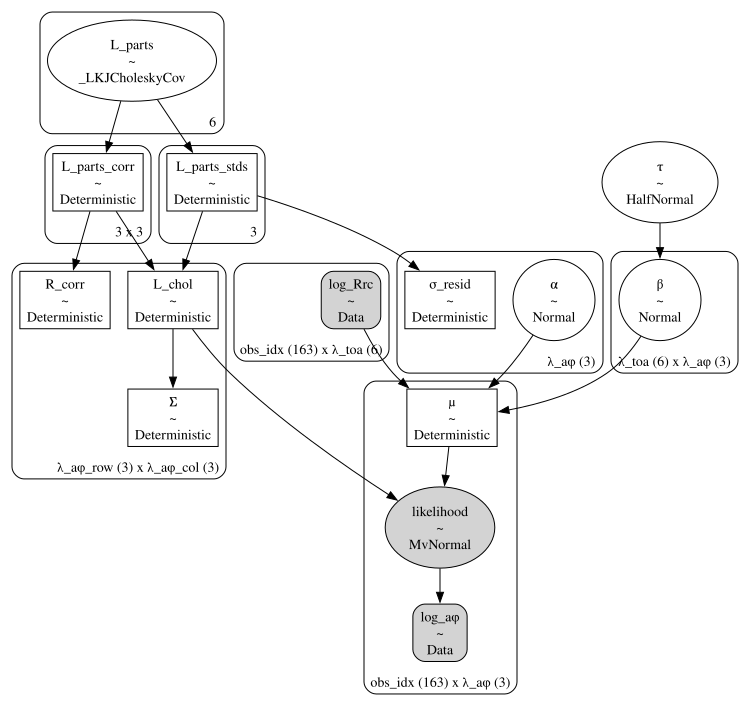

In [41]:
g = m_lin_mvn.to_graphviz()
g

In [42]:
g.render("m4_mvn_dag", directory=str(DIR["figs"]/ "si"), format="pdf", cleanup=True)
g.render("m4_mvn_dag", directory=str(DIR['figs'] / 'portfolio'), format='png', cleanup=True)

'/Users/erdemkarakoylu/projex/bayesian_toa_2_iop/figs/portfolio/m4_mvn_dag.png'

#### 3) Prior predictive check (gate) 
- MVN prior predictive spans plausible ranges and cross-band structure

In [101]:
with m_lin_mvn:
    idata_lin_mvn = pm.sample_prior_predictive()

Sampling: [L_parts, likelihood, α, β, τ]


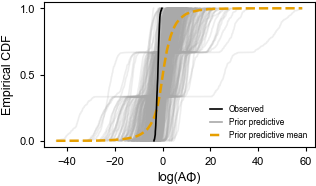

In [121]:
fig, ax = fig_ax(width="one", aspect=0.62)
az.plot_ppc(
    idata_mvn, group='prior', kind='cumulative', 
    colors=PPC_COLORS, observed=True, ax=ax)

ax.set_xlabel('log(AΦ)')
ax.set_ylabel('Empirical CDF')
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_prior_ppc_mvn.pdf")


---
#### 4) Posterior sampling (NUTS)


In [ ]:
with m_lin_mvn:
    idata_lin_mvn.extend(
        pm.sample(
            chains=4, tune=2500, draws=2000, init="jitter+adapt_diag", 
            nuts_sampler_kwargs=dict(target_accept=0.95, max_treedepth=15)))


#### 5) Sampling diagnostics
##### a. Summary statistics

In [116]:
summ = az.summary(idata_mvn, var_names=["τ","σ_resid","β"])
summ

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
τ,2.363,0.427,1.580,3.146,0.017,0.007,654.0,1703.0,1.01
σ_resid[443],0.194,0.011,0.174,0.216,0.000,0.000,933.0,2026.0,1.00
σ_resid[555],0.324,0.019,0.292,0.360,0.001,0.000,1178.0,2214.0,1.00
σ_resid[670],0.236,0.014,0.209,0.260,0.000,0.000,895.0,2231.0,1.00
"β[412, 443]",2.141,0.722,0.760,3.454,0.032,0.014,523.0,1132.0,1.00
"β[412, 555]",0.782,1.065,-1.220,2.760,0.043,0.021,610.0,1210.0,1.00
"β[412, 670]",0.395,0.801,-0.996,1.985,0.034,0.015,560.0,1255.0,1.00
"β[443, 443]",-3.809,1.096,-5.860,-1.812,0.041,0.021,733.0,1717.0,1.00
"β[443, 555]",-2.013,1.564,-4.848,1.013,0.053,0.028,890.0,1577.0,1.00
"β[443, 670]",-0.179,1.212,-2.329,2.262,0.041,0.022,861.0,1920.0,1.00


In [117]:
summ["rMCSE_mean"] = summ["mcse_mean"] / summ["sd"]
summ["rMCSE_sd"]   = summ["mcse_sd"]   / summ["sd"]
summ[["rMCSE_mean","rMCSE_sd","ess_bulk","ess_tail","r_hat"]].describe()

,rMCSE_mean,rMCSE_sd,ess_bulk,ess_tail,r_hat
count,22.000000,22.000000,22.000000,22.000000,22.000000
mean,0.037567,0.015515,677.681818,1581.590909,1.005455
std,0.013038,0.006407,189.769380,336.748127,0.005096
min,0.000000,0.000000,423.000000,1014.000000,1.000000
25%,0.037461,0.016419,532.250000,1333.000000,1.000000
50%,0.039984,0.017857,662.500000,1570.000000,1.010000
75%,0.044267,0.018611,782.500000,1775.500000,1.010000
max,0.052632,0.019718,1178.000000,2231.000000,1.010000


#### b. Energy plots

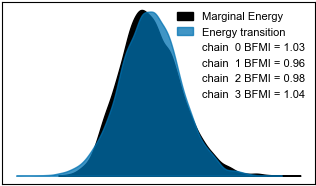

In [114]:
fig, ax = fig_ax()
az.plot_energy(idata_mvn, ax=ax)
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_m4_energy.pdf")

#### c. Trace plots

Note that not all parameters can be plotted.

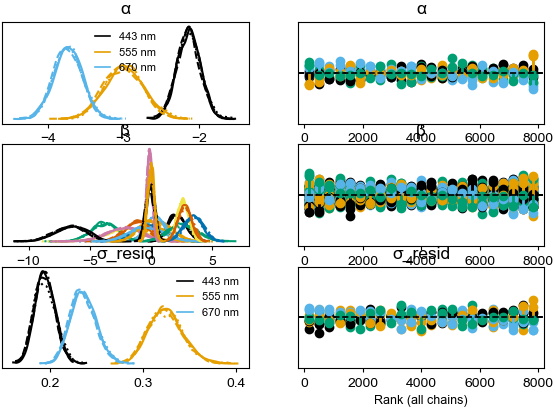

In [127]:
axs = az.plot_trace(
    idata_mvn,
    var_names=["α", "β", "σ_resid"],         # combine selections
    compact=True, kind="rank_vlines",
    figsize=(7.0, 4.5))
axs[0, 0].legend(handles=legend_handles)
axs[2, 0].legend(handles=legend_handles)

f = pp.gcf()
f.savefig(DIR["figs"]/"si"/"figS_m4_trace.pdf"); 

#### 6) Posterior predictive checks & log-likelihood
##### a. Posterior Predictive Checks
###### - 3-way posterior predictive check

In [ ]:
with m_lin_mvn:    
    pm.sample_posterior_predictive(idata_mvn, extend_inferencedata=True)

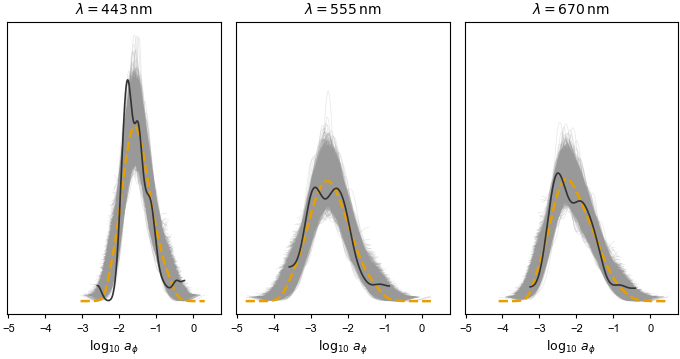

In [128]:
f, axs = plot_3_way_ppc(
    idata=idata_mvn, var="likelihood",
    out=DIR["figs"] / "si" / f"figS_m4_ppc.pdf"
    )
f.savefig(DIR['figs'] / 'portfolio' /'m4_ppc.png')

##### - Prior vs posterior predictive

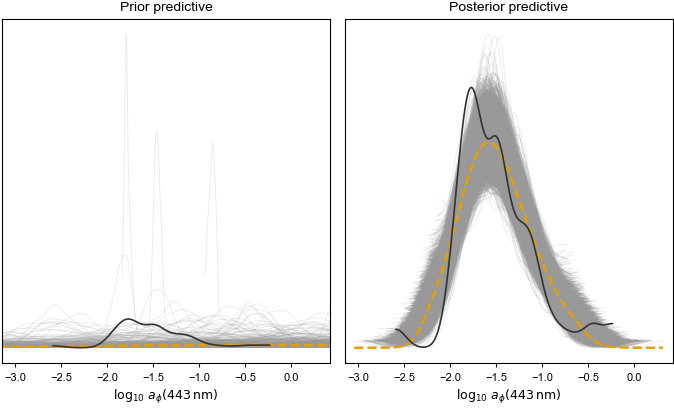

In [129]:
band = 443
f, axs=compare_ppc(
    idata_mvn, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m4_compare_ppc_{band}.pdf"
)

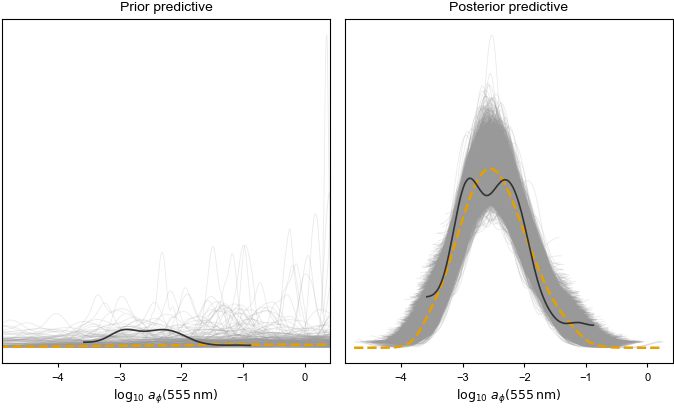

In [130]:
band = 555
f, axs=compare_ppc(
    idata_mvn, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m4_compare_ppc_{band}.pdf"
)

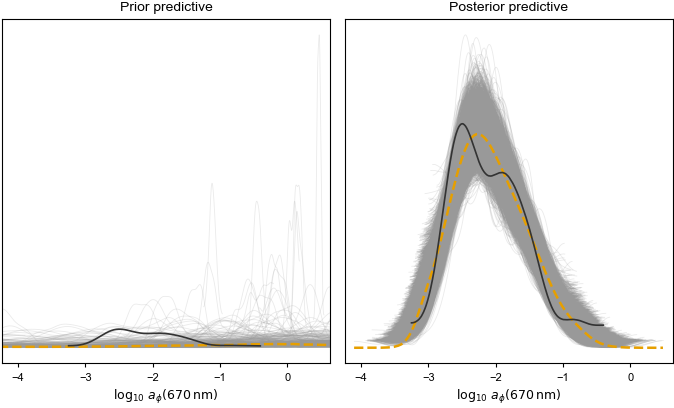

In [131]:
band = 670
f, axs=compare_ppc(
    idata_mvn, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m4_compare_ppc_{band}.pdf"
)

##### b. Coverage and Uncertainty Calibration
###### - Coverage

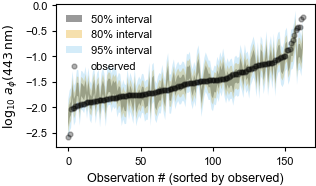

In [132]:
# SI Figure: HDI ribbons vs observed (band 443)
band=443
f, ax = plot_regression_hdi(
    idata_mvn, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_mvn.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /f'm4_hdi_{band}.png', )

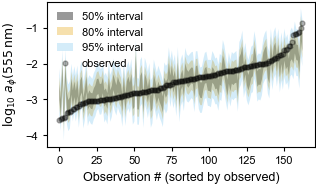

In [134]:
# SI Figure: HDI ribbons vs observed (band 443)
band=555
f, ax = plot_regression_hdi(
    idata_mvn, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_mvn.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /f'm4_hdi_{band}.png', )

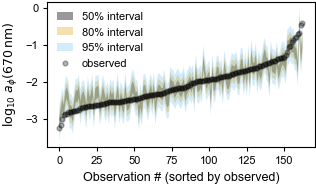

In [135]:
# SI Figure: HDI ribbons vs observed (band 443)
band=670
f, ax = plot_regression_hdi(
    idata_mvn, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_mvn.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /f'm4_hdi_{band}.png', )

In [137]:
# (Optional) SI Table: Coverage per band
cov_mvn = posterior_coverage(idata_mvn, var="likelihood")
cov_mvn.to_csv(DIR["results"]/ "coverage_mvn.csv", index=False)
cov_mvn.round(2)

,interval,band,coverage,nominal
0,95%,443,0.96,0.95
1,95%,555,0.96,0.95
2,95%,670,0.94,0.95
3,80%,443,0.85,0.80
4,80%,555,0.87,0.80
5,80%,670,0.83,0.80
6,50%,443,0.53,0.50
7,50%,555,0.53,0.50
8,50%,670,0.57,0.50


/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hd

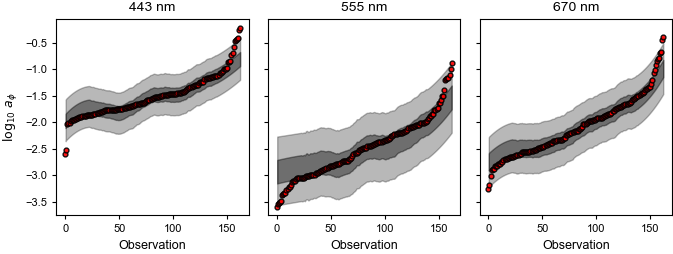

In [33]:
bands = [443, 555, 670]
fig, axes = pp.subplots(1, len(bands), figsize=(7.0, 7.0*0.4), sharey=True)

stats_list = []
for i, (ax_i, b) in enumerate(zip(axes, bands)):
    df_b = plot_ppc_hdi_band_multi(
        idata=idata_mvn, band=b, hdi_probs=(0.95, 0.50),
        sort_by="observed", ax=ax_i  # <- draw into existing axes
    )
    stats_list.append(df_b)
    ax_i.set_title(f"{b} nm")  # optional; your call
    if i > 0: ax_i.set_ylabel('')  # only leftmost panel
fig.tight_layout()
save_pnas(fig, "figs/si/figS_m4_ppc_multi")
fig.savefig(DIR['figs'] / 'portfolio' /'m4_ppc_multi.png', )
stats_all_mvn = pd.concat(stats_list, ignore_index=True)  # table-ready

In [30]:
stats_all_mvn

,band,hdi_prob,n_obs,max_width_log,median_width_log,p90_width_log,max_factor,median_factor,p90_factor,factor_base
0,443,0.95,163,0.811742,0.774646,0.792002,6.482495,5.951775,6.194435,10.0
1,555,0.95,163,1.352238,1.295421,1.319638,22.502887,19.743351,20.875561,10.0
2,670,0.95,163,0.981907,0.939829,0.960916,9.591947,8.706217,9.139374,10.0


<u>**Predictive uncertainty by band — MVN model (95% posterior predictive HDI; n = 163 per band)**</u>

These summaries report the **vertical span** of the posterior predictive highest-density interval (HDI) for each observation, in **log10 units** (widths) and as **multiplicative factors** (×). Because these are **posterior predictive** intervals, they combine both mean-function and residual uncertainty.

* 443 nm
  - **Median span:** 0.775 log10 → **×5.95**
  - **P90 span:** 0.792 log10 → **×6.19**
  - **Maximum span:** 0.812 log10 → **×6.48**

*Interpretation:* Typical uncertainty is ~6× (well below a full order of magnitude).

* 555 nm
  - **Median span:** 1.295 log10 → **×19.74**
  - **P90 span:** 1.320 log10 → **×20.88**
  - **Maximum span:** 1.352 log10 → **×22.50**

*Interpretation:* This band shows the **largest predictive uncertainty**—~20× on typical observations (well over one order of magnitude).

* 670 nm
  - **Median span:** 0.940 log10 → **×8.71**
  - **P90 span:** 0.961 log10 → **×9.14**
  - **Maximum span:** 0.982 log10 → **×9.59**

*Interpretation:* Typical uncertainty is just under one order of magnitude; the widest envelopes are ~9.6×.

**Cross-band takeaway (MVN).** Predictive uncertainty is **lowest at 443 nm** (~6×), **highest at 555 nm** (~20–23×), and **intermediate at 670 nm** (~9–10×), mirroring the familiar blue < red < green pattern in uncertainty magnitude.


###### - PPC + LOO-PIT

In [ ]:

with m_mvn:
    pm.compute_log_likelihood(idata_mvn, extend_inferencedata=True)

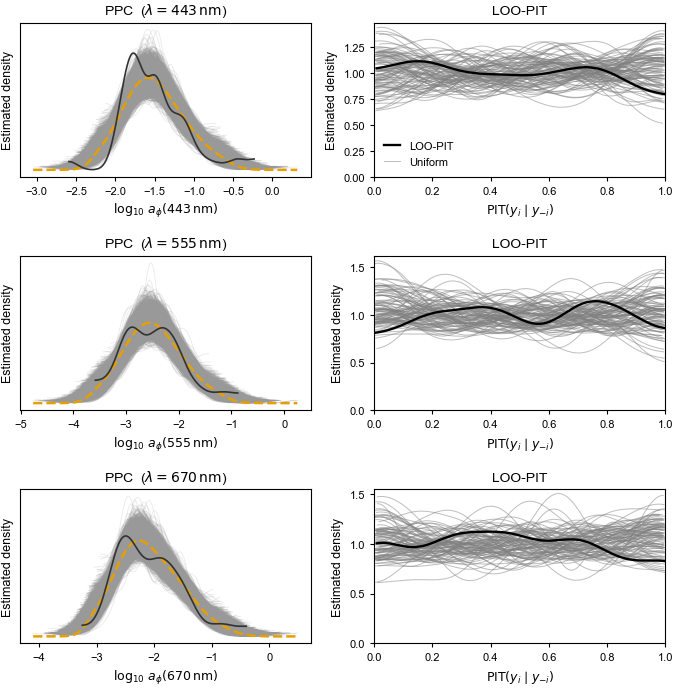

In [144]:
# All three bands in one 3×2 figure
f, axs = plot_ppc_pit_grid(
    idata_mvn, var="likelihood",
    out=DIR["figs"]/ "si"/ "figS_ppc_pit_grid_mvn.pdf"
)
f.savefig(DIR['figs'] / 'portfolio' /'m4_ppc_pit_grid.png', )

###### - LOO-PIT quality assessment via Pareto-k influential observations


In [138]:
loo_results = az.loo(idata_mvn)
print(loo_results)

Computed from 8000 posterior samples and 163 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   173.50    28.61
p_loo       29.26        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      162   99.4%
   (0.70, 1]   (bad)         1    0.6%
   (1, Inf)   (very bad)    0    0.0%



/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [139]:
loo = az.loo(idata_mvn, pointwise=True)
k_values = loo.pareto_k.values
influential_idx = (k_values > 0.7).nonzero()[0]
print("Influential observations:", influential_idx)

Influential observations: [110]


/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [140]:
idx, k, loo = find_influential_observations(
    idata_mvn, threshold=0.7,
    save_csv=DIR["results"] / "loo_pareto_k_mvn.csv"
)
print("Influential observations:", idx.tolist())

Influential observations: [110]


/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


##### 7) Save Inference Data object

In [ ]:
save_idata(idata_mvn, DIR["idata"], "Linear (full Σ)")

## Comparing the four models:

### Coverage comparison: Cross-model takeaway (95% posterior predictive HDIs; n = 163 per band)

**Big picture.** The three linear-family models—**linear**, **hierarchical linear**, and **MVN**—produce **similar, comparatively tight** predictive intervals. **BART** yields **much wider** posterior predictive intervals across all bands.

**Overall ordering (least → most uncertain):**  
**Hierarchical linear ≈ MVN ≈ Linear**  ≪  **BART**

**Typical (median) 95% HDI spans by band (multiplicative × factors):**
- **443 nm:** Linear **×6.13** · Hier. Linear **×5.80** · MVN **×5.95** · **BART ×30.43**
- **555 nm:** Linear **×20.93** · Hier. Linear **×18.79** · MVN **×19.74** · **BART ×131.21**
- **670 nm:** Linear **×9.73** · Hier. Linear **×8.47** · MVN **×8.71** · **BART ×96.48**

**Shared cross-band pattern.** All models show **lowest uncertainty at 443 nm**, **highest at 555 nm**, and **intermediate at 670 nm**.

**Interpretation.**
- The linear-family models are **calibrated to comparable dispersion levels**; added structure (hierarchical pooling, MVN residuals) does **not** materially inflate or deflate predictive spread relative to the simple linear baseline.
- **BART’s** posterior predictive is **5–10× wider** than the linear-family medians, band by band. This can still achieve coverage but indicates **much lower sharpness** (probability mass spread thinly over large ranges).

**What this comparison is (and isn’t).**  
These HDI widths summarize **predictive dispersion** (how wide intervals are). They **do not** by themselves adjudicate model *skill*; for that, pair them with **calibration** (coverage, LOO-PIT) and **out-of-sample accuracy** (ELPD-LOO, CRPS). Here, the dispersion view says: *linear-family ~ tight and similar; BART ~ much wider*.


### LOO-Based Model Comparison

#### Problem for Independent vs Multivariate Models comparison with ArviZ

###### The issue
ArviZ is great but one runs into bookkeeping issues when comparing models with different output structures.

* In an MVN model, likelihood ~ MvNormal(mu=μ, chol=L, observed=Y_data) has event shape = K (the bands). ArviZ stores the pointwise log-likelihood with dims (chain, draw, obs_idx) — one value per observation.

* In the independent-Normal model(s), likelihood ~ Normal(..., observed=Y_data, dims=['obs_idx','λ_aφ']) has no event dim; ArviZ stores one log-lik per element with dims (chain, draw, obs_idx, λ_aφ).

##### WHy?
Because in PyMC the event dimension is a property of the distribution itself, not something you change by passing dims=.

* pm.MvNormal(...) is vector-valued: it has event_dim = 1 by design. Whatever axis you line up with the vector (your λ_aφ) is treated as the event. Log-probability is summed over that axis internally, so you get one logp per obs_idx. Your dims=['obs_idx','λ_aφ'] just labels axes of the observed array; it does not change the fact that the last axis is an event axis.
* pm.Normal(..., observed=Y, dims=['obs_idx','λ_aφ']) is scalar-valued: it has event_dim = 0. Both axes are treated as batch axes (independent elements). Logp is computed per element, so ArviZ stores (chain, draw, obs_idx, λ_aφ).

##### When the problem arises and symptoms:
When one calls az.compare(ic="loo"), ArviZ expects the same number of pointwise log-likelihood entries across models. Independent and MvN models are N vs N×K, respectively, hence an error will occur.

##### Possible solutions:

For all models to yield one pointwise log-likelihood per observation (to compare with LOO):

1. Either cast the independent model as a diagonal multivariate:

```python
L_diag = pt.diag(σ)  # σ dims 'λ_aφ'
pm.MvNormal('likelihood', mu=μ, chol=L_diag,
            observed=Y_data, dims=['obs_idx','λ_aφ'])
```

2. Or tell PyMC to treat the band axis as an event by wrapping with pm.Independent:

```python
base = pm.Normal.dist(mu=μ, sigma=σ, dims=['obs_idx','λ_aφ'])
pm.Independent('likelihood', base, reinterpreted_batch_ndim=1,
               observed=Y_data, dims=['obs_idx','λ_aφ'])
```

3. Or post-process ArviZ: idata.log_likelihood['likelihood'] = idata.log_likelihood['likelihood'].sum('λ_aφ').

So: dims= assigns names/shape; event vs batch (what gets summed in logp) is determined by the distribution (MvNormal vs Normal) or by explicitly reinterpreting batch dims with pm.Independent.

##### Solution adopted here (avoids refitting models):

One needs to make every model’s pointwise log-likelihood have the same event structure (one value per obs_idx). For any model that stored log_likelihood with an extra band axis (λ_aφ), just sum over that axis. Below is a small, robust helper that:
* checks that log_likelihood exists (and tells you if it doesn’t),
* collapses any extra axes beyond obs_idx (e.g., λ_aφ) so shapes match the MVN,
* returns a new dict ready for az.compare.

In [ ]:
def harmonize_idata_ll(idata, obs_dim="obs_idx"):
    """Return a shallow-copied InferenceData whose log_likelihood
    is collapsed to one value per observation (obs_dim)."""
    if not hasattr(idata, "log_likelihood"):
        raise ValueError("InferenceData lacks a log_likelihood group. "
                         "Sample with idata_kwargs={'log_likelihood': True} or compute it first.")

    id_copy = idata.copy()
    # Pick the (only) observed var name in log_likelihood
    ll_vars = list(id_copy.log_likelihood.data_vars)
    if len(ll_vars) != 1:
        # If multiple, pick the first or adapt as needed
        var = ll_vars[0]
    else:
        var = ll_vars[0]

    ll = id_copy.log_likelihood[var]  # e.g., dims: (chain, draw, obs_idx, λ_aφ)
    # Sum over any dims that are not chain/draw/obs_dim
    extra_dims = [d for d in ll.dims if d not in ("chain", "draw", obs_dim)]
    if extra_dims:
        ll = ll.sum(extra_dims)

    # Write back
    id_copy.log_likelihood[var] = ll
    return id_copy

# ---- Harmonize all your models (except MVN which is already per-obs) ----
models_raw = dict(
    model_lin=idata_lin, 
    model_bart=idata_bart,
    model_hier_lin=idata_hier,
    model_lin_mvn=idata_mvn            # MVN already per-obs; can include as-is
)

models_harmonized = {}
for name, idata in models_raw.items():
    try:
        models_harmonized[name] = harmonize_idata_ll(idata, obs_dim="obs_idx")
    except ValueError as e:
        print(f"[{name}] {e}")  # reminds you to re-sample with log_likelihood=True or compute it

# If MVN already produces per-obs loglik, you can add it directly:
#models_harmonized["model_lin_mvn"] = idata_lin_mvn

# ---- Compare ----
comparison_2 = az.compare(models_harmonized, ic="loo", method="BB-pseudo-BMA")
comparison_2


/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampli

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model_lin_mvn,0,173.496441,29.256730,0.000000,1.000000e+00,29.147792,0.000000,True,log
model_hier_lin,1,-11.192800,24.885168,184.689241,1.330201e-47,31.104385,20.986645,False,log
model_lin,2,-30.609364,19.107634,204.105805,4.522480e-50,30.413698,22.350394,False,log
model_bart,3,-339.169079,86.665211,512.665520,1.231413e-146,33.229556,32.732176,True,log


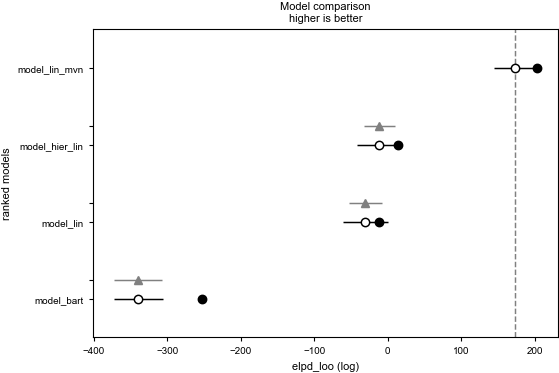

In [148]:
ax = az.plot_compare(comparison_2, plot_ic_diff=True, insample_dev=True)

## Overarching report: predictive uncertainty (coverage tables) vs model comparison (LOO)

### Executive summary
- **Uncertainty (HDI widths):** The three linear-family models—**linear**, **hierarchical linear**, and **MVN**—exhibit **similar and comparatively tight** 95% posterior predictive intervals across bands (∼×6 at 443 nm, ∼×19–21 at 555 nm, ∼×9–10 at 670 nm). **BART** is **much wider** (∼×30, ×131, ×96 respectively).
- **Predictive fit (LOO):** **MVN** decisively leads in **ELPD-LOO** (rank 0, weight ≈ 1), with linear and hierarchical linear far behind, and BART last.
- **Reconciliation:** Coverage/widths summarize **dispersion**; LOO measures **out-of-sample log predictive density** (calibrated **and** sharp). MVN wins because it keeps intervals reasonably tight **and** places **more probability mass near realized outcomes**, especially via multivariate residual structure.

---

### Evidence from coverage tables (95% HDI widths)
- **Shared cross-band pattern:** All models show **lowest uncertainty at 443 nm**, **highest at 555 nm**, **intermediate at 670 nm**—a consistent difficulty gradient (blue < red < green in uncertainty magnitude).
- **Linear-family parity:** Linear, hierarchical linear, and MVN differ modestly (typically within ~10–15% on medians). Added structure (partial pooling, MVN residuals) **does not inflate** uncertainty relative to the baseline linear model.
- **BART dispersion:** BART’s envelopes are **5–10× wider** than linear-family medians at each band. Wide intervals can still achieve nominal coverage but indicate **low sharpness** (probability mass spread thin).

---

### Evidence from model comparison (PSIS-LOO)
- **MVN leads by a large margin:** Highest **ELPD-LOO**, large **elpd_diff** vs others, implying **substantial per-observation gains** in log predictive density. As a rule of thumb, ~1 nat/obs ≈ **e¹ ≈ 2.7×** average density gain per point; your differences are large enough to be practically decisive.
- **Why MVN helps:** Modeling **residual correlation across bands** allows the model to assign **higher joint probability** to observed multi-band outcomes, improving LOO without needing broader intervals.
- **BART’s low LOO despite good coverage:** The extreme **over-dispersion** (very wide predictive intervals) spreads density thin, **penalizing log scores** even if coverage looks acceptable.

---

### Reconciling coverage with LOO
- **Coverage checks calibration**, not sharpness. Many distributions can hit 95% coverage:
  - **Too wide:** good coverage, poor sharpness → lower log density.
  - **Too narrow:** poor coverage → lower log density.
  - **Well-calibrated & sharp:** good coverage **and** high log density.
- **LOO rewards the last case.** MVN is calibrated enough **and** sharper, so it dominates in LOO.

---

### Notes on diagnostics & robustness
- **Pareto-k warnings:** You observed 1 “bad” point (0.7–1) for MVN and none for BART, yet a warning flag appears for both in the comparison table. This can arise from:
  - **Pointwise log-likelihood harmonization** (summing over output dims) changing tail behavior of importance weights.
  - Minor differences between the objects passed to `compare` and what you inspected separately.  
  **Action:** Re-check **pareto-k** on the exact harmonized `InferenceData` used in `az.compare`. For any points with k > 0.7, consider **reloo** or a small **K-fold** to confirm rankings; given the large elpd gaps, the ordering is very unlikely to flip.
- **Bandwise contributions:** Given the green band (555 nm) dominates uncertainty across models, MVN’s advantage likely comes from **leveraging cross-band covariance** to place mass in the right joint regions.

---

### Practical implications
- **Model choice:** Prefer **MVN** for inference and prediction; it provides **sharper**, better-calibrated predictive densities out-of-sample.
- **Communication:** Report both **interval widths (intuitive spans)** and **LOO (skill)**. For example: “At 443 nm, typical predictive span is ~×6; MVN achieves the highest ELPD-LOO, indicating sharper, better-calibrated predictions than alternatives.”
- **Uncertainty management:** The **555 nm** band drives much of the predictive uncertainty. Consider targeted **modeling refinements** or **data improvements** (e.g., additional covariates, noise modeling, instrument characterization) for that band.

---

### Recommended next steps
1. **Calibration checks:** Add **empirical coverage**, **LOO-PIT**, and **CRPS** per model/band to complement widths.
2. **Robustness:** For the few high k points, run **reloo** or a **K-fold** subset; confirm MVN’s lead.
3. **Ablations:** Verify the **incremental gain** from residual correlation (MVN) by comparing to the same linear mean without cross-band covariance.
4. **Ensembling:** Compute **stacking weights**; with current gaps, MVN will dominate, but stacking confirms whether any complementary signal exists.
